# MDC vNext -- Drift-Aware System + Baselines + Thesis Figures (KAGGLE)

**KAGGLE version:** no Google Drive, no Colab. Self-contained: upload only this
notebook. All artifacts live under `/kaggle/working/`.

| Subfolder | Contents |
|-----------|----------|
| `processed/` | `windows_vnext.npz`, drift baseline, mc npz |
| `runs/` | checkpoint, scores, metrics, ablations |
| `drift_aware/` | this notebook's outputs |

**Handoff between notebooks:** attach the producing notebook's output via
'+ Add Data > Your Notebooks', or download its zip and upload it as a new
Kaggle Dataset then attach that -- see `mdc_preprocess_vNext_kaggle.ipynb`'s
title cell for the full pattern.


## 0. Environment

In [4]:
import sys, os, subprocess
from pathlib import Path
_IN_KAGGLE = os.path.exists('/kaggle/working')
if _IN_KAGGLE:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'torch', 'scikit-learn', 'matplotlib'], check=False)
    # Eval utils are embedded in §3b -- no separate .py upload
print(f'In Kaggle: {_IN_KAGGLE}')


In Kaggle: True


## 1. Configuration

In [5]:
from __future__ import annotations
import os, json, gc, math, time, shutil
from pathlib import Path
from datetime import datetime, timezone
import numpy as np

VERSION = 'vnext'
SEED = 42
np.random.seed(SEED)

# --- Drift-aware hyperparams (WBS §2.1–2.3) ---
ADAPTIVE_ALPHA        = 2.5
BENIGN_BUFFER_SIZE    = 500      # was 100; aligned to proposal's stated 500-1000 sample window (re-run to check impact on claim_ok)
THRESHOLD_UPDATE_EVERY= 20
PSI_CHECK_EVERY       = 100
PSI_TRIGGER           = 0.10      # mean PSI across features
DRIFT_SLICE_FRAC      = 0.30        # last 30% of stream = drift period
STABLE_SLICE_FRAC     = 0.70
FINETUNE_STEPS        = 50
FINETUNE_LR           = 1e-5
FINETUNE_BENIGN_N     = 200
RUN_ALPHA_SWEEP       = True        # sensitivity analysis for thesis
ALPHA_SWEEP_VALUES    = (1.5, 2.0, 2.5, 3.0)
MATCHED_FPR_TARGETS   = (0.05, 0.10, 0.25)  # research operating points
# Adaptive-threshold estimator (Root-cause fix, see docs/MODULE4_ADAPTIVE_THRESHOLD_FIX_PLAN.md):
# median+alpha*std overshoots the score ceiling on this dataset's heavy-tailed benign
# score distribution (verified: 0 alerts fired across the whole 5,153-step stream at
# every alpha in ALPHA_SWEEP_VALUES). 'quantile' is the fixed default; 'median_std' is
# kept selectable so both can be reported side by side as an ablation.
ADAPTIVE_ESTIMATOR    = 'quantile'   # 'quantile' (fixed) | 'median_std' (legacy, ablation only)
ADAPTIVE_TARGET_PCTL  = 72.0         # initial/fallback value -- overridden by the Phase 1 validation sweep below if enabled
# Phase 1-4 improvement plan (see docs/MODULE4_ADAPTIVE_THRESHOLD_IMPROVEMENT_PLAN.md):
# the estimator fix (above) made the mechanism functional; these four levers are
# aimed at closing the remaining performance gap vs. the fixed threshold.
RUN_PCTL_SWEEP_ON_VAL      = True   # Phase 1: tune target_percentile on validation data, not by hand
ADAPTIVE_PCTL_SWEEP_VALUES = (50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0)
ADAPTIVE_RECALL_TOL        = 0.05   # matches the claim_ok gate's recall tolerance
ADAPTIVE_F1_TOL            = 0.02   # matches the claim_ok gate's F1 tolerance
RUN_SMOOTHING_SWEEP_ON_VAL = True   # Phase 2: tune threshold_smoothing on validation, not by hand
ADAPTIVE_SMOOTHING_SWEEP_VALUES = (0.0, 0.2, 0.3, 0.5, 0.7, 0.85)
ADAPTIVE_SMOOTHING_MIN_GAIN     = 0.01  # only adopt smoothing>0 if it beats smoothing=0 by at least this much (val fpr_reduction)
ADAPTIVE_SMOOTHING        = 0.0     # initial/fallback value -- overridden by the Phase 2 validation sweep if enabled
ADAPTIVE_PSI_GATE          = True   # Phase 3: only deviate from the fixed thr when PSI > trigger
ADAPTIVE_USE_ENVELOPE      = True   # Phase 4: clip adaptive thr to a validation-derived envelope around fixed
# Integrity gates (Task 1/3) — refuse invalid adaptive comparisons
THR_F1_TOL            = 0.05
THR_FPR_TOL           = 0.10
THR_MAX_SANE_FPR      = 0.50

# --- Scoring (match model vNext) ---
SCORE_MEAN_W = 0.3
SCORE_MAX_W  = 0.7
SCORE_BATCH_SIZE = 128
BATCH_SIZE = 32

DATA_DIR = Path('/kaggle/working/processed')   if _IN_KAGGLE else Path('../outputs/vNEXT_test/processed')
RUN_DIR  = Path('/kaggle/working/runs')        if _IN_KAGGLE else Path('../outputs/vNEXT_test/runs')
OUT_DIR  = Path('/kaggle/working/drift_aware') if _IN_KAGGLE else Path('../outputs/vNEXT_test/drift_aware')
for _p in (DATA_DIR, RUN_DIR, OUT_DIR):
    Path(_p).mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / 'thesis_figures_300dpi'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Config loaded')
print(f'  DATA_DIR (use) : {DATA_DIR}')
print(f'  RUN_DIR (use)  : {RUN_DIR}')
print(f'  OUT_DIR        : {OUT_DIR}')

Config loaded
  DATA_DIR (use) : /kaggle/working/processed
  RUN_DIR (use)  : /kaggle/working/runs
  OUT_DIR        : /kaggle/working/drift_aware


## 2. Load artifacts (Kaggle input / working dir -- no Drive)


In [6]:
# --- Kaggle IO helpers (self-contained -- no Drive, no Colab) ---
import os, sys, glob, shutil, zipfile, base64
from pathlib import Path

_IN_KAGGLE = os.path.exists('/kaggle/working')

KAGGLE_WORKING = Path('/kaggle/working')
KAGGLE_INPUT   = Path('/kaggle/input')

def kaggle_find(name, extra_dirs=()):
    """Search /kaggle/input/**, /kaggle/working/**, and extra_dirs for a file by
    name. There is no live shared Drive on Kaggle -- to hand a file from one
    notebook to the next, either (a) attach the producing notebook's own
    output via '+ Add Data > Your Notebooks' (no manual zip needed), or
    (b) download this notebook's output zip and upload it as a new Kaggle
    Dataset, then attach that dataset. Either way it shows up under
    /kaggle/input/<name>/ and this function finds it there."""
    roots = [KAGGLE_INPUT, KAGGLE_WORKING, *[Path(d) for d in extra_dirs]]
    for root in roots:
        if not root.is_dir():
            continue
        hits = sorted(glob.glob(str(root / '**' / name), recursive=True))
        if hits:
            return Path(hits[0])
    return None

def kaggle_upload_fallback(name, dest_dir):
    """Best-effort interactive upload widget for a live session. Not available
    during a headless 'Save & Run All' commit (no UI) -- attach the file as
    input data instead in that case."""
    try:
        import ipywidgets as widgets
        from IPython.display import display
        uploader = widgets.FileUpload(accept='', multiple=False)
        display(uploader)
        print(f'Upload {name} with the widget above, then re-run this cell.')
        if uploader.value:
            item = list(uploader.value.values())[0]
            content = item['content'] if isinstance(item, dict) else item.content
            dest = Path(dest_dir) / name
            dest.parent.mkdir(parents=True, exist_ok=True)
            dest.write_bytes(bytes(content))
            print(f'Saved -> {dest}')
            return dest
    except Exception as e:
        print(f'Interactive upload unavailable ({e}).')
    return None

def zip_and_offer_download(src_dir, zip_name, max_auto_mb=25):
    """Zip src_dir into /kaggle/working/{zip_name}.zip and try to trigger a
    browser download automatically. Only fires in a live, actively-open
    browser tab (not during headless 'Save & Run All') -- Kaggle's own Output
    tab (right sidebar) always lists this zip for manual download regardless
    of whether the auto-download trick actually fires in your browser."""
    src_dir = Path(src_dir)
    zip_base = KAGGLE_WORKING / zip_name
    zip_path = zip_base.with_suffix('.zip')
    if zip_path.exists():
        zip_path.unlink()
    shutil.make_archive(str(zip_base), 'zip', root_dir=src_dir)
    size_mb = zip_path.stat().st_size / 1024 / 1024
    print(f'Zipped -> {zip_path}  ({size_mb:.1f} MB)')
    if size_mb <= max_auto_mb:
        try:
            from IPython.display import HTML, display
            b64 = base64.b64encode(zip_path.read_bytes()).decode()
            html = (
                f'<a id="dl_{zip_name}" download="{zip_path.name}" '
                f'href="data:application/zip;base64,{b64}"></a>'
                f'<script>document.getElementById("dl_{zip_name}").click();</script>'
            )
            display(HTML(html))
            print('Auto-download triggered (only works if this tab is actively open --')
            print('if nothing happened, use the Output tab on the right instead).')
        except Exception as e:
            print(f'Auto-download trick failed ({e}) -- use the Output tab instead.')
    else:
        print(f'{size_mb:.1f} MB exceeds the {max_auto_mb} MB auto-download guard -- '
              'skipping the browser trick to avoid bloating notebook output.')
        print('Get it from the Output tab (right sidebar) after Save Version instead.')
    return zip_path

print(f'Kaggle IO ready. In Kaggle: {_IN_KAGGLE}')

NPZ_FILE   = f'windows_{VERSION}.npz'
DRIFT_FILE = f'drift_baseline_{VERSION}.npz'
RUN_ARTIFACTS = [
    'checkpoint_vnext.pt', 'scores_vnext.npz', 'metrics_vnext.json',
    'drift_report_vnext.npz', 'eval_vnext.png',
    'eval_per_attack_type.png', 'eval_per_attack_roc.png', 'eval_multiclass.json',
    'metrics_ablation_vnext.json', 'ablation_retrain_table.csv',
]

def _resolve(name, dest_dir):
    hit = kaggle_find(name)
    if hit is None:
        print(f'{name} not found under /kaggle/input or /kaggle/working.')
        hit = kaggle_upload_fallback(name, dest_dir)
    return hit

hit = _resolve(NPZ_FILE, DATA_DIR)
if hit is None:
    raise FileNotFoundError(
        f"Missing {NPZ_FILE}. Run mdc_preprocess_vNext_kaggle.ipynb first and attach "
        "its output via '+ Add Data', or upload it manually."
    )
NPZ_PATH = DATA_DIR / hit.name
if hit.resolve() != NPZ_PATH.resolve():
    shutil.copy2(hit, NPZ_PATH)

drift_hit = kaggle_find(DRIFT_FILE)
DRIFT_PATH = DATA_DIR / DRIFT_FILE
if drift_hit is not None and drift_hit.resolve() != DRIFT_PATH.resolve():
    shutil.copy2(drift_hit, DRIFT_PATH)

required_run = ['scores_vnext.npz', 'metrics_vnext.json']
optional_run = ['checkpoint_vnext.pt']

for name in required_run:
    src_p = _resolve(name, RUN_DIR)
    if src_p is None:
        raise FileNotFoundError(
            f"Missing {name}. Run mdc_model_vNext_kaggle.ipynb first and attach its "
            "output via '+ Add Data', or upload it manually."
        )
    dest = RUN_DIR / name
    if src_p.resolve() != dest.resolve():
        shutil.copy2(src_p, dest)

for name in optional_run:
    src_p = kaggle_find(name)
    if src_p is not None:
        dest = RUN_DIR / name
        if src_p.resolve() != dest.resolve():
            shutil.copy2(src_p, dest)
        print(f'  OK optional {name}')
    else:
        print(f'  WARN missing {name} -- \u00a73 model load will fail until you add it to runs/')

for name in RUN_ARTIFACTS:
    if name in required_run or name in optional_run:
        continue
    src_p = kaggle_find(name)
    if src_p is not None:
        dest = RUN_DIR / name
        if src_p.resolve() != dest.resolve():
            try:
                shutil.copy2(src_p, dest)
            except Exception as e:
                print(f'  skip optional {name}: {e}')

CKPT_PATH = RUN_DIR / 'checkpoint_vnext.pt'
SCORES_PATH = RUN_DIR / 'scores_vnext.npz'
METRICS_PATH = RUN_DIR / 'metrics_vnext.json'

print(f'OK npz     : {NPZ_PATH} ({NPZ_PATH.stat().st_size:,})')
for _label, _p in [('ckpt', CKPT_PATH), ('scores', SCORES_PATH), ('metrics', METRICS_PATH)]:
    if _p.is_file():
        print(f'OK {_label:8s}: {_p} ({_p.stat().st_size:,})')
    else:
        print(f'MISSING {_label:8s}: {_p}')
if not CKPT_PATH.is_file():
    print('WARNING: checkpoint_vnext.pt missing -- upload it before \u00a73 model cell')

z = np.load(NPZ_PATH, allow_pickle=True)
X_train = z['X_train'].astype(np.float32)
X_val   = z['X_val'].astype(np.float32)
X_test  = z['X_test'].astype(np.float32)
y_val   = z['y_val'].astype(np.int8)
y_test  = z['y_test'].astype(np.int8)
c_test  = z['c_test'] if 'c_test' in z.files else None
ts_test = z['ts_test'] if 'ts_test' in z.files else None
ts_val  = z['ts_val']  if 'ts_val'  in z.files else None
T, n_features = X_test.shape[1], X_test.shape[2]
z.close()

if ts_test is not None:
    _ts_span_h = (float(ts_test.max()) - float(ts_test.min())) / 3600.0
    print(f'ts_test available: unix [{int(ts_test.min())}, {int(ts_test.max())}]  span={_ts_span_h:.1f}h')
    print('Task 6: temporal streaming ENABLED (ordering_mode will be timestamp)')
else:
    print('ts_test not in npz — stream uses container_lexsort proxy')
    print('Task 6: re-run mdc_preprocess_vNext.ipynb to export ts_val/ts_test into windows_vnext.npz')

scores_z = np.load(SCORES_PATH)
s_val  = scores_z['s_val']
s_test = scores_z['s_test']
scores_z.close()

metrics = json.loads(METRICS_PATH.read_text())
SCORE_INVERT = bool(metrics.get('auto_score_flip', True))
ALERT_INVERT = False
print(f'Loaded windows: train={X_train.shape} val={X_val.shape} test={X_test.shape}')
print(f'SCORE_INVERT={SCORE_INVERT}  (how scores were produced in model notebook)')
print(f'ALERT_INVERT={ALERT_INVERT}  (saved scores already higher=anomalous)')

drift_z = None
if DRIFT_PATH.is_file():
    drift_z = np.load(DRIFT_PATH, allow_pickle=True)
    print(f'Drift baseline: {drift_z["mean"].shape[0]} features')
else:
    print('WARN: drift_baseline missing — PSI trigger will use feature-mean proxy')


Kaggle IO ready. In Kaggle: True
  OK optional checkpoint_vnext.pt
OK npz     : /kaggle/working/processed/windows_vnext.npz (27,738,649)
OK ckpt    : /kaggle/working/runs/checkpoint_vnext.pt (2,356,857)
OK scores  : /kaggle/working/runs/scores_vnext.npz (40,644)
OK metrics : /kaggle/working/runs/metrics_vnext.json (4,151)
ts_test available: unix [1679230305, 1715107245]  span=9965.8h
Task 6: temporal streaming ENABLED (ordering_mode will be timestamp)
Loaded windows: train=(16795, 10, 163) val=(5153, 10, 163) test=(5153, 10, 163)
SCORE_INVERT=True  (how scores were produced in model notebook)
ALERT_INVERT=False  (saved scores already higher=anomalous)
Drift baseline: 163 features


## 3. Model + scoring (load checkpoint, no retrain)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, matthews_corrcoef,
    balanced_accuracy_score, confusion_matrix, roc_curve,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Paths should come from the Drive/load cell; define fallbacks if that cell was skipped
if 'CKPT_PATH' not in globals():
    CKPT_PATH = RUN_DIR / 'checkpoint_vnext.pt'
    SCORES_PATH = RUN_DIR / 'scores_vnext.npz'
    METRICS_PATH = RUN_DIR / 'metrics_vnext.json'
    print(f'CKPT_PATH was undefined — using fallback RUN_DIR={RUN_DIR}')

if not CKPT_PATH.is_file():
    raise FileNotFoundError(
        f'Missing checkpoint: {CKPT_PATH}\n'
        f'Attach it via + Add Data, or upload it into {RUN_DIR} manually.'
    )

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
feat_std = ckpt.get('feat_std')

# scores_vnext.npz was saved from the DEFAULT model (§8/§17), not HPO model_best.
# model_best uses different arch (dim_ff=192, bn=16, 3 enc layers) -> size mismatch if mis-loaded.
USE_HPO_MODEL = False

def _arch_from_config(cfg):
    d_model = cfg['d_model']
    return dict(
        d_model=d_model,
        nhead=cfg['nhead'],
        num_enc_layers=cfg['num_enc_layers'],
        num_dec_layers=cfg['num_dec_layers'],
        dim_ff=cfg['dim_ff'],
        dropout=cfg['dropout'],
        bottleneck_dim=cfg['bottleneck_dim'],
    )

def _arch_from_hpo(hp):
    d_model = hp['d_model']
    return dict(
        d_model=d_model,
        nhead=4 if d_model % 4 == 0 else 2,
        num_enc_layers=hp['num_enc_layers'],
        num_dec_layers=hp['num_dec_layers'],
        dim_ff=hp['dim_ff'],
        dropout=hp['dropout'],
        bottleneck_dim=hp['bottleneck_dim'],
    )

if USE_HPO_MODEL and ckpt.get('model_best') is not None and ckpt.get('hpo_params'):
    arch = _arch_from_hpo(ckpt['hpo_params'])
    state_key = 'model_best'
    model_tag = 'HPO best'
else:
    arch = _arch_from_config(ckpt['config'])
    state_key = 'model_default' if ckpt.get('model_default') is not None else 'model_best'
    model_tag = 'default (matches scores_vnext.npz)'

D_MODEL = arch['d_model']; BOTTLENECK_DIM = arch['bottleneck_dim']
N_HEAD = arch['nhead']; N_ENC = arch['num_enc_layers']; N_DEC = arch['num_dec_layers']
DIM_FF = arch['dim_ff']; DROPOUT = arch['dropout']
print(f'Loading checkpoint key={state_key!r}  tag={model_tag}')
print(f'  arch: d={D_MODEL} bn={BOTTLENECK_DIM} ff={DIM_FF} enc={N_ENC} dec={N_DEC}')

class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class SequenceBottleneckAE(nn.Module):
    def __init__(self, n_features, d_model=D_MODEL, nhead=N_HEAD,
                 num_enc_layers=N_ENC, num_dec_layers=N_DEC,
                 dim_ff=DIM_FF, dropout=DROPOUT, bottleneck_dim=BOTTLENECK_DIM,
                 max_len=200):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pe = SinusoidalPE(d_model, max_len=max_len, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
        self.bn_down = nn.Sequential(nn.Linear(d_model, bottleneck_dim),
                                     nn.LayerNorm(bottleneck_dim), nn.GELU())
        self.bn_up = nn.Linear(bottleneck_dim, d_model)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)
        self.output_proj = nn.Linear(d_model, n_features)
        self.pos_queries = nn.Parameter(torch.zeros(max_len, d_model))
    def encode(self, x):
        return self.bn_down(self.encoder(self.pe(self.input_proj(x))))
    def forward(self, x):
        B, T_, _ = x.shape
        z = self.encode(x)
        memory = self.bn_up(z)
        tgt = self.pe(self.pos_queries[:T_].unsqueeze(0).expand(B, -1, -1))
        return self.output_proj(self.decoder(tgt, memory))

def _combine(err, mean_w=SCORE_MEAN_W, max_w=SCORE_MAX_W):
    return mean_w * err.mean(dim=(1, 2)) + max_w * err.mean(dim=2).amax(dim=1)

@torch.no_grad()
def compute_scores(X, _model, feat_std_=None, invert=None, bs=SCORE_BATCH_SIZE):
    if invert is None: invert = SCORE_INVERT
    _model.eval()
    out = []
    for k in range(0, len(X), bs):
        xb = torch.from_numpy(X[k:k+bs]).float().to(device)
        rb = _model(xb)
        err = (rb - xb).pow(2)
        if feat_std_ is not None:
            w = torch.from_numpy(feat_std_).float().to(device).clamp(min=1e-6)
            err = err / w[None, None, :]
        out.append(_combine(err).cpu().numpy())
    s = np.concatenate(out)
    return -s if invert else s


# Ensure windows/scores/metrics are loaded (if Drive/load cell was skipped mid-run)
import json as _json
from pathlib import Path as _P
import numpy as np

if 'n_features' not in globals() or 'X_test' not in globals():
    _data = _P(globals().get('DATA_DIR', '.'))
    _run = _P(globals().get('RUN_DIR', '.'))
    _npz = globals().get('NPZ_PATH') or (_data / 'windows_vnext.npz')
    _npz = _P(_npz)
    if not _npz.is_file():
        raise FileNotFoundError(f'Missing windows npz: {_npz}')
    _z = np.load(_npz, allow_pickle=True)
    X_train = _z['X_train'].astype(np.float32)
    X_val   = _z['X_val'].astype(np.float32)
    X_test  = _z['X_test'].astype(np.float32)
    y_val   = _z['y_val'].astype(np.int8)
    y_test  = _z['y_test'].astype(np.int8)
    c_test  = _z['c_test'] if 'c_test' in _z.files else None
    ts_test = _z['ts_test'] if 'ts_test' in _z.files else None
    ts_val  = _z['ts_val']  if 'ts_val'  in _z.files else None
    T, n_features = int(X_test.shape[1]), int(X_test.shape[2])
    _z.close()
    print(f'Auto-loaded windows from {_npz}: T={T} n_features={n_features}')

if 's_test' not in globals() or 'metrics' not in globals():
    _run = _P(globals().get('RUN_DIR', '.'))
    _sp = _P(globals().get('SCORES_PATH', _run / 'scores_vnext.npz'))
    _mp = _P(globals().get('METRICS_PATH', _run / 'metrics_vnext.json'))
    _sz = np.load(_sp)
    s_val, s_test = _sz['s_val'], _sz['s_test']
    _sz.close()
    metrics = _json.loads(_mp.read_text())
    SCORE_INVERT = bool(metrics.get('auto_score_flip', True))
    ALERT_INVERT = False
    print(f'Auto-loaded scores/metrics from {_run}')

model = SequenceBottleneckAE(n_features, max_len=max(T + 10, 200)).to(device)
state = ckpt[state_key]
model.load_state_dict(state)
model.eval()
print(f'Model loaded — params={sum(p.numel() for p in model.parameters()):,}')

# Sanity: recomputed scores should match saved scores_vnext.npz
_s_chk = compute_scores(X_test[:512], model, feat_std)
_auc_saved = roc_auc_score(y_test[:512], s_test[:512])
_auc_recomp = roc_auc_score(y_test[:512], _s_chk)
print(f'AUC check (first 512 windows): saved={_auc_saved:.4f}  recompute={_auc_recomp:.4f}')
if abs(_auc_saved - _auc_recomp) > 0.05:
    print('WARN: large AUC gap — check USE_HPO_MODEL / SCORE_INVERT / feat_std')

Device: cpu
Loading checkpoint key='model_default'  tag=default (matches scores_vnext.npz)
  arch: d=64 bn=24 ff=256 enc=2 dec=2
Model loaded — params=270,571
AUC check (first 512 windows): saved=0.6400  recompute=0.6401


/tmp/ipykernel_108/3813195411.py:96: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


## 3b. Evaluation helpers

Readable Python source for alert-space scoring, threshold integrity, matched-FPR comparison, and stream ordering. Run once; binds `ev` for later cells.


In [8]:
# Evaluation helpers — readable source (best practice for notebooks)
# Run once before §4. Source of truth in repo: notebook/mdc_eval_utils.py.

"""
MDC vNext — shared evaluation utilities for drift-aware monitoring experiments.

Design principles (research + engineering):
- Alert-space scoring: unified direction where higher score = more anomalous.
  Adaptive thresholds operate in this space.
- Score convention (critical): `compute_scores(..., invert=SCORE_INVERT)` already
  negates reconstruction error when auto_score_flip=True. Saved scores in
  scores_vnext.npz are therefore ALREADY higher=anomalous. Use ALERT_INVERT=False
  for predict_alerts / adaptive on saved scores. Do NOT pass SCORE_INVERT again
  (that double-inverts and yields ~97% FPR — the v1 drift-run failure mode).
- Offline threshold: load thr from metrics_vnext.json test_default.f1_optimal
  (same operating point as the model notebook). Never recompute with a different
  invert convention for the stream fixed baseline.
- Stream ordering: prefer per-window timestamps when available; fall back to
  container lexsort for backward-compatible npz artifacts.
- Baselines: Isolation Forest trained on benign-only data with temporal pooling
  (mean + max) rather than destructive flattening.
"""
from __future__ import annotations

from dataclasses import dataclass, field, asdict
from typing import Any, Callable, Dict, Iterable, List, Optional, Sequence, Tuple, Union

import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
)


# ---------------------------------------------------------------------------
# Alert-space scoring
# ---------------------------------------------------------------------------

def to_alert_score(scores: np.ndarray, invert: bool) -> np.ndarray:
    """Map raw AE scores to alert space (higher = more anomalous)."""
    s = np.asarray(scores, dtype=np.float64)
    return -s if invert else s.copy()


def alert_threshold_from_raw(threshold_raw: float, invert: bool) -> float:
    """Convert a threshold tuned on raw scores into alert-space."""
    return float(-threshold_raw if invert else threshold_raw)


def raw_threshold_from_alert(threshold_alert: float, invert: bool) -> float:
    """Inverse of alert_threshold_from_raw (for logging / plots)."""
    return float(-threshold_alert if invert else threshold_alert)


def predict_alerts(
    scores_raw: np.ndarray,
    threshold_raw: float,
    invert: bool,
) -> np.ndarray:
    """Binary predictions in unified alert space."""
    s_alert = to_alert_score(scores_raw, invert)
    thr_alert = alert_threshold_from_raw(threshold_raw, invert)
    return (s_alert >= thr_alert).astype(np.int8)


def compute_adaptive_threshold(
    benign_alert_scores: Sequence[float],
    alpha: float = 2.5,
    min_samples: int = 5,
    estimator: str = "quantile",
    target_percentile: float = 72.0,
    max_seen: Optional[float] = None,
) -> float:
    """
    Benign-calibrated adaptive threshold in alert space.

    estimator="median_std" (legacy): threshold = median(benign) + alpha*std(benign).
    Kept only for ablation - on this dataset the benign score distribution is
    heavy-tailed (std comparable in magnitude to the median itself), so
    median+alpha*std reliably overshoots the achievable score range within the
    first few hundred calibration samples, producing zero alerts for the rest
    of the stream regardless of alpha (verified for alpha in [1.5, 3.0] -
    see docs/MODULE4_ADAPTIVE_THRESHOLD_FIX_PLAN.md).

    estimator="quantile" (default): threshold = quantile(benign, target_percentile).
    A sample quantile is always within the sample's own observed range, so it
    cannot overshoot a hard score ceiling the way a parametric mean/median +
    k*sigma rule can under heavy-tailed data.

    `max_seen`, if given, is a hard governor: never return a threshold above
    the highest alert-space score observed anywhere in the stream so far,
    since such a threshold could never be crossed again by any future window.
    """
    buf = np.asarray(benign_alert_scores, dtype=np.float64)
    if len(buf) < min_samples:
        thr = float(np.median(buf)) if len(buf) else 0.0
    elif estimator == "median_std":
        thr = float(np.median(buf) + alpha * np.std(buf))
    elif estimator == "quantile":
        thr = float(np.quantile(buf, target_percentile / 100.0))
    else:
        raise ValueError(f"Unknown estimator: {estimator!r}")
    if max_seen is not None and thr > max_seen:
        thr = float(max_seen)
    return thr


# ---------------------------------------------------------------------------
# Threshold search + classification metrics
# ---------------------------------------------------------------------------

def thresholds_from_val(
    scores_val: np.ndarray,
    labels_val: np.ndarray,
    invert: bool = False,
) -> Dict[str, float]:
    """F1-optimal and Youden thresholds on validation (raw score convention)."""
    s = np.asarray(scores_val, dtype=np.float64)
    y = np.asarray(labels_val, dtype=np.int8)
    fpr, tpr, thr = roc_curve(y, s)
    youden = tpr - fpr
    i_y = int(np.argmax(youden))
    best_f1, best_thr = 0.0, float(np.median(s))
    for t in np.unique(np.percentile(s, np.linspace(1, 99, 60))):
        pred = predict_alerts(s, float(t), invert)
        f1 = f1_score(y, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, float(t)
    return {"youden": float(thr[i_y]), "f1_optimal": best_thr}


def resolve_offline_threshold(
    metrics: Dict[str, Any],
    primary: str = "f1_optimal",
) -> Dict[str, Any]:
    """
    Load the offline-tuned threshold from metrics_vnext.json.

    Research rule: stream fixed-threshold evaluation MUST use the same
    operating point as the model notebook (test_default.f1_optimal), not a
    recomputed threshold that may use a different invert convention.
    """
    if "test_default" not in metrics:
        raise KeyError("metrics_vnext.json missing test_default")
    block = metrics["test_default"][primary]
    if "threshold" not in block:
        raise KeyError(f"test_default.{primary} missing 'threshold' key")
    return {
        "thr_raw": float(block["threshold"]),
        "primary": primary,
        "source": f"metrics_vnext.json:test_default.{primary}.threshold",
        "offline_roc_auc": float(block.get("roc_auc", float("nan"))),
        "offline_f1": float(block.get("f1", float("nan"))),
        "offline_mcc": float(block.get("mcc", float("nan"))),
        "offline_recall": float(block.get("recall", float("nan"))),
        "offline_fpr": float(block.get("fpr", float("nan"))),
        "offline_precision": float(block.get("precision", float("nan"))),
    }


def validate_threshold_integrity(
    labels: np.ndarray,
    scores_raw: np.ndarray,
    threshold_raw: float,
    invert: bool,
    offline: Optional[Dict[str, Any]] = None,
    *,
    f1_tol: float = 0.05,
    fpr_tol: float = 0.10,
    max_sane_fpr: float = 0.50,
    raise_on_fail: bool = True,
) -> Dict[str, Any]:
    """
    Research integrity gate for fixed-threshold evaluation.

    Catches the double-invert / wrong-threshold failure mode that produced
    ~97% stream FPR in the v1 drift-aware run.
    """
    m = classification_metrics(labels, scores_raw, threshold_raw, invert)
    checks: Dict[str, Any] = {
        "thr_raw": float(threshold_raw),
        "alert_invert": bool(invert),
        "observed": m,
        "pass_sane_fpr": bool(m["fpr"] <= max_sane_fpr),
        "pass_f1_match": True,
        "pass_fpr_match": True,
        "ok": True,
        "failures": [],
    }
    if not checks["pass_sane_fpr"]:
        checks["failures"].append(
            f"fixed FPR={m['fpr']:.3f} > {max_sane_fpr} "
            "(likely double-invert or wrong threshold)"
        )
    if offline is not None:
        off_f1 = offline.get("offline_f1")
        off_fpr = offline.get("offline_fpr")
        if off_f1 is not None and np.isfinite(off_f1):
            checks["pass_f1_match"] = bool(abs(m["f1"] - off_f1) <= f1_tol)
            if not checks["pass_f1_match"]:
                checks["failures"].append(
                    f"F1 mismatch: observed={m['f1']:.4f} offline={off_f1:.4f} "
                    f"(tol={f1_tol})"
                )
        if off_fpr is not None and np.isfinite(off_fpr):
            checks["pass_fpr_match"] = bool(abs(m["fpr"] - off_fpr) <= fpr_tol)
            if not checks["pass_fpr_match"]:
                checks["failures"].append(
                    f"FPR mismatch: observed={m['fpr']:.4f} offline={off_fpr:.4f} "
                    f"(tol={fpr_tol})"
                )
    checks["ok"] = (
        checks["pass_sane_fpr"]
        and checks["pass_f1_match"]
        and checks["pass_fpr_match"]
    )
    if raise_on_fail and not checks["ok"]:
        raise RuntimeError(
            "THRESHOLD INTEGRITY FAIL — refuse invalid adaptive comparison.\n"
            + "\n".join(f"  - {x}" for x in checks["failures"])
            + "\nFix: load thr from metrics_vnext.json and use ALERT_INVERT=False "
            "on saved scores (already higher=anomalous)."
        )
    return checks


def classification_metrics(
    labels: np.ndarray,
    scores_raw: np.ndarray,
    threshold_raw: float,
    invert: bool,
) -> Dict[str, float]:
    """Full metric bundle at a fixed raw threshold."""
    y = np.asarray(labels, dtype=np.int8)
    s = np.asarray(scores_raw, dtype=np.float64)
    pred = predict_alerts(s, threshold_raw, invert)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "roc_auc": float(roc_auc_score(y, s)),
        "pr_auc": float(average_precision_score(y, s)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "precision": float(tp / max(tp + fp, 1)),
        "recall": float(tp / max(tp + fn, 1)),
        "mcc": float(matthews_corrcoef(y, pred)),
        "bal_acc": float(balanced_accuracy_score(y, pred)),
        "fpr": float(fp / max(fp + tn, 1)),
        "fnr": float(fn / max(fn + tp, 1)),
        "thr_raw": float(threshold_raw),
        "thr_alert": alert_threshold_from_raw(threshold_raw, invert),
    }


def recall_at_target_fpr(
    labels: np.ndarray,
    scores_raw: np.ndarray,
    target_fpr: float,
) -> float:
    """TPR at a target FPR from ROC curve (score-direction agnostic)."""
    y = np.asarray(labels, dtype=np.int8)
    s = np.asarray(scores_raw, dtype=np.float64)
    fpr, tpr, _ = roc_curve(y, s)
    i = int(np.searchsorted(fpr, target_fpr))
    i = min(i, len(tpr) - 1)
    return float(tpr[i])


def threshold_at_target_fpr(
    labels: np.ndarray,
    scores_raw: np.ndarray,
    target_fpr: float,
    invert: bool = False,
) -> Dict[str, float]:
    """
    Find a raw threshold whose FPR is closest to target_fpr (ROC operating point).

    Scores must already be in the convention used by `invert` (for saved
    scores_vnext.npz use invert=False — higher = more anomalous).
    """
    y = np.asarray(labels, dtype=np.int8)
    s_alert = to_alert_score(scores_raw, invert)
    fpr, tpr, thr_alert = roc_curve(y, s_alert)
    i = int(np.argmin(np.abs(fpr - target_fpr)))
    thr_a = float(thr_alert[i]) if np.isfinite(thr_alert[i]) else float(np.median(s_alert))
    thr_raw = raw_threshold_from_alert(thr_a, invert)
    m = classification_metrics(y, scores_raw, thr_raw, invert)
    return {
        "target_fpr": float(target_fpr),
        "thr_raw": thr_raw,
        "thr_alert": thr_a,
        "achieved_fpr": m["fpr"],
        "recall": m["recall"],
        "f1": m["f1"],
        "mcc": m["mcc"],
        "precision": m["precision"],
        "roc_tpr_at_index": float(tpr[i]),
    }


def matched_recall_at_fpr(
    labels: np.ndarray,
    scores_raw: np.ndarray,
    threshold_raw: float,
    invert: bool,
    target_fpr: float,
) -> Dict[str, float]:
    """
    Score-quality operating point vs fixed-threshold natural point.

    - fixed_* : metrics at the offline-tuned threshold
    - roc_*   : metrics if threshold were set to target_fpr on this slice
    """
    y = np.asarray(labels, dtype=np.int8)
    s = np.asarray(scores_raw, dtype=np.float64)
    fixed = classification_metrics(y, s, threshold_raw, invert)
    at_target = threshold_at_target_fpr(y, s, target_fpr, invert=invert)
    return {
        "target_fpr": float(target_fpr),
        "fixed_recall": fixed["recall"],
        "fixed_fpr": fixed["fpr"],
        "fixed_f1": fixed["f1"],
        "fixed_mcc": fixed["mcc"],
        "roc_recall_at_target_fpr": at_target["recall"],
        "roc_f1_at_target_fpr": at_target["f1"],
        "roc_mcc_at_target_fpr": at_target["mcc"],
        "roc_achieved_fpr": at_target["achieved_fpr"],
        "roc_thr_raw": at_target["thr_raw"],
    }


def matched_policy_comparison(
    labels: np.ndarray,
    scores_raw: np.ndarray,
    fixed_threshold_raw: float,
    invert: bool,
    stream_eval: Dict[str, Any],
    alpha_sweep: Optional[Sequence[Dict[str, Any]]] = None,
    target_fprs: Sequence[float] = (0.05, 0.10, 0.25),
    half_idx: Optional[int] = None,
) -> Dict[str, Any]:
    """
    Research-grade fixed vs adaptive comparison at matched operating points.

    Reports:
      1. Natural operating points (last-half fixed vs adaptive)
      2. Score ROC TPR/F1 @ {5%,10%,25%} FPR (policy-independent)
      3. Alpha-matched row: alpha whose last-half FPR is closest to fixed FPR
      4. Fixed-at-adaptive-FPR: fixed threshold retuned to adaptive's FPR
    """
    y = np.asarray(labels, dtype=np.int8)
    s = np.asarray(scores_raw, dtype=np.float64)
    n = len(y)
    if half_idx is None:
        half_idx = n // 2
    y_last = y[half_idx:]
    s_last = s[half_idx:]

    fixed_last = stream_eval["fixed_last_half"]
    adapt_last = stream_eval["adaptive_last_half"]

    roc_ops = {
        f"fpr_{int(t * 100)}": matched_recall_at_fpr(
            y_last, s_last, fixed_threshold_raw, invert, float(t)
        )
        for t in target_fprs
    }

    # Retune fixed threshold on last-half to adaptive's achieved FPR
    adapt_fpr = float(adapt_last["fpr"])
    fixed_at_adapt_fpr = threshold_at_target_fpr(
        y_last, s_last, adapt_fpr, invert=invert
    )

    alpha_matched: Optional[Dict[str, Any]] = None
    if alpha_sweep:
        target = float(fixed_last["fpr"])
        best = min(alpha_sweep, key=lambda r: abs(float(r["fpr_last_half"]) - target))
        alpha_matched = {
            "alpha": float(best["alpha"]),
            "adaptive_fpr": float(best["fpr_last_half"]),
            "adaptive_recall": float(best["recall_last_half"]),
            "adaptive_f1": float(best["f1_last_half"]),
            "fixed_fpr": float(fixed_last["fpr"]),
            "fixed_recall": float(fixed_last["recall"]),
            "fixed_f1": float(fixed_last["f1"]),
            "fpr_gap": abs(float(best["fpr_last_half"]) - target),
            "f1_delta": float(best["f1_last_half"]) - float(fixed_last["f1"]),
            "recall_delta": float(best["recall_last_half"]) - float(fixed_last["recall"]),
            "note": (
                "Compare F1/recall only when fpr_gap is small; "
                "otherwise report as unmatched trade-off."
            ),
        }

    # Thesis-safe claim gate: do not claim FPR reduction without F1/recall context
    fpr_reduction = float(stream_eval.get("fpr_reduction_last_half", 0.0))
    f1_gain = float(stream_eval.get("f1_gain_last_half", 0.0))
    recall_delta = float(stream_eval.get("recall_delta_last_half", 0.0))
    claim_ok = bool(
        fpr_reduction > 0.0
        and f1_gain >= -0.02
        and recall_delta >= -0.05
        and float(fixed_last["fpr"]) <= 0.50
    )

    return {
        "slice": "last_half",
        "natural": {
            "fixed": fixed_last,
            "adaptive": adapt_last,
            "fpr_reduction": fpr_reduction,
            "f1_gain": f1_gain,
            "recall_delta": recall_delta,
        },
        "roc_operating_points_last_half": roc_ops,
        "fixed_retuned_to_adaptive_fpr": fixed_at_adapt_fpr,
        "alpha_matched_to_fixed_fpr": alpha_matched,
        "claim_adaptive_improves_without_recall_loss": claim_ok,
        "interpretation": (
            "adaptive_supported"
            if claim_ok
            else (
                "tradeoff_or_negative — report F1/recall/MCC; "
                "do not claim FPR reduction alone"
            )
        ),
    }


# ---------------------------------------------------------------------------
# Stream ordering
# ---------------------------------------------------------------------------

def stream_order_indices(
    n: int,
    container_ids: Optional[np.ndarray] = None,
    timestamps: Optional[np.ndarray] = None,
) -> np.ndarray:
    """
    Determine replay order for simulated streaming evaluation.

    Priority:
      1. Per-window timestamps (true temporal order when exported by preprocess)
      2. Lexsort by container ID (pseudo-chronological proxy)
      3. Identity order (raw test index)
    """
    if timestamps is not None and len(timestamps) == n:
        ts = np.asarray(timestamps, dtype=np.float64)
        if np.any(np.isfinite(ts)) and np.nanstd(ts) > 0:
            return np.argsort(ts, kind="stable")
    if container_ids is not None and len(container_ids) == n:
        c = np.asarray(container_ids)
        return np.lexsort((np.arange(n), c))
    return np.arange(n, dtype=np.int64)


def describe_stream_order(
    order: np.ndarray,
    timestamps: Optional[np.ndarray] = None,
    container_ids: Optional[np.ndarray] = None,
) -> Dict[str, Any]:
    """Metadata for thesis Methods section (ordering assumption documentation)."""
    mode = "identity"
    if timestamps is not None and len(timestamps) == len(order):
        ts = np.asarray(timestamps, dtype=np.float64)
        if np.any(np.isfinite(ts)) and np.nanstd(ts) > 0:
            mode = "timestamp"
    elif container_ids is not None:
        mode = "container_lexsort"
    return {
        "ordering_mode": mode,
        "n_windows": int(len(order)),
        "note": (
            "Simulated streaming replay — not live deployment. "
            "See thesis_drift_aware_notes.md for interpretation."
        ),
    }


# ---------------------------------------------------------------------------
# Adaptive threshold streaming simulation
# ---------------------------------------------------------------------------

@dataclass
class AdaptiveThresholdSimulator:
    """Stateful benign-buffer adaptive threshold along a score stream.

    Phase 2/3/4 additions (see docs/MODULE4_ADAPTIVE_THRESHOLD_IMPROVEMENT_PLAN.md):
    - threshold_smoothing: EWMA blend with the previous threshold, so one
      volatile update can't swing the operating point as far.
    - envelope_delta_alert: hard cap on how far the threshold may deviate from
      the fixed offline value, in alert space (validation-calibrated).
    - drift_active (passed to observe(), not stored here): when False, the
      simulator reports the fixed threshold instead of its recalibrated one,
      while still accumulating the benign buffer underneath.
    """

    alpha: float = 2.5
    buffer_size: int = 100
    update_every: int = 20
    invert: bool = True
    initial_threshold_raw: float = 0.0
    min_benign_for_update: int = 5
    estimator: str = "quantile"
    target_percentile: float = 72.0
    threshold_smoothing: float = 0.0
    envelope_delta_alert: Optional[float] = None

    benign_alert_buf: List[float] = field(default_factory=list)
    threshold_trace_alert: List[float] = field(default_factory=list)
    threshold_trace_raw: List[float] = field(default_factory=list)
    current_threshold_alert: float = 0.0
    current_threshold_raw: float = 0.0
    _max_alert_seen: float = field(default=-np.inf, repr=False)
    _fixed_threshold_alert: float = field(default=0.0, repr=False)

    def __post_init__(self) -> None:
        self.current_threshold_alert = alert_threshold_from_raw(
            self.initial_threshold_raw, self.invert
        )
        self.current_threshold_raw = float(self.initial_threshold_raw)
        self._fixed_threshold_alert = self.current_threshold_alert

    def _maybe_update(self, step: int) -> None:
        if (step + 1) % self.update_every != 0:
            return
        if len(self.benign_alert_buf) < self.min_benign_for_update:
            return
        candidate_alert = compute_adaptive_threshold(
            self.benign_alert_buf,
            alpha=self.alpha,
            estimator=self.estimator,
            target_percentile=self.target_percentile,
            max_seen=self._max_alert_seen,
        )
        if self.threshold_smoothing > 0.0:
            # Phase 2: blend with the previous threshold so a single volatile
            # buffer snapshot can't move the operating point too far in one step.
            candidate_alert = (
                self.threshold_smoothing * self.current_threshold_alert
                + (1.0 - self.threshold_smoothing) * candidate_alert
            )
        if self.envelope_delta_alert is not None:
            # Phase 4: structural safety rail -- never stray further than
            # envelope_delta_alert from the fixed offline threshold.
            lo = self._fixed_threshold_alert - self.envelope_delta_alert
            hi = self._fixed_threshold_alert + self.envelope_delta_alert
            candidate_alert = float(np.clip(candidate_alert, lo, hi))
        self.current_threshold_alert = candidate_alert
        self.current_threshold_raw = raw_threshold_from_alert(
            self.current_threshold_alert, self.invert
        )

    def observe(self, score_raw: float, label: int, step: int, drift_active: bool = True) -> float:
        """Process one stream step; returns current raw threshold.

        drift_active (Phase 3): when False, report the fixed offline
        threshold instead of the recalibrated one -- the benign buffer keeps
        accumulating regardless, so a real transition is picked up
        immediately once drift_active flips True. Default True preserves the
        original always-adapting behaviour for callers that don't pass it.
        """
        alert_s = float(to_alert_score(np.array([score_raw]), self.invert)[0])
        if alert_s > self._max_alert_seen:
            self._max_alert_seen = alert_s
        if label == 0:
            self.benign_alert_buf.append(alert_s)
            if len(self.benign_alert_buf) > self.buffer_size:
                self.benign_alert_buf.pop(0)
        self._maybe_update(step)
        if not drift_active:
            self.current_threshold_alert = self._fixed_threshold_alert
            self.current_threshold_raw = self.initial_threshold_raw
        self.threshold_trace_alert.append(self.current_threshold_alert)
        self.threshold_trace_raw.append(self.current_threshold_raw)
        return self.current_threshold_raw

    def predict(self, score_raw: float) -> int:
        return int(
            to_alert_score(np.array([score_raw]), self.invert)[0]
            >= self.current_threshold_alert
        )


def evaluate_stream_strategies(
    labels: np.ndarray,
    scores_raw: np.ndarray,
    fixed_threshold_raw: float,
    invert: bool,
    simulator: AdaptiveThresholdSimulator,
    half_idx: Optional[int] = None,
    drift_mask: Optional[np.ndarray] = None,
) -> Dict[str, Any]:
    """
    Compare fixed vs adaptive threshold along a stream.

    drift_mask (Phase 3, optional): boolean array aligned to `labels`/`scores_raw`.
    Where False, the adaptive simulator reports the fixed threshold for that
    step instead of its recalibrated one (see AdaptiveThresholdSimulator.observe).
    None (default) means always-adapting, matching the original behaviour.

    Returns global and half-stream metrics (FPR, recall, F1, MCC).
    """
    y = np.asarray(labels, dtype=np.int8)
    s = np.asarray(scores_raw, dtype=np.float64)
    n = len(y)
    if half_idx is None:
        half_idx = n // 2

    fixed_pred = predict_alerts(s, fixed_threshold_raw, invert)
    adapt_pred = np.zeros(n, dtype=np.int8)

    sim = AdaptiveThresholdSimulator(
        alpha=simulator.alpha,
        buffer_size=simulator.buffer_size,
        update_every=simulator.update_every,
        invert=invert,
        initial_threshold_raw=fixed_threshold_raw,
        min_benign_for_update=simulator.min_benign_for_update,
        estimator=simulator.estimator,
        target_percentile=simulator.target_percentile,
        threshold_smoothing=simulator.threshold_smoothing,
        envelope_delta_alert=simulator.envelope_delta_alert,
    )

    for t in range(n):
        da = bool(drift_mask[t]) if drift_mask is not None else True
        sim.observe(float(s[t]), int(y[t]), t, drift_active=da)
        adapt_pred[t] = sim.predict(float(s[t]))

    def _slice_metrics(pred: np.ndarray, sl: slice) -> Dict[str, float]:
        ys, ss, ps = y[sl], s[sl], pred[sl]
        tn, fp, fn, tp = confusion_matrix(ys, ps, labels=[0, 1]).ravel()
        return {
            "fpr": float(fp / max(fp + tn, 1)),
            "fnr": float(fn / max(fn + tp, 1)),
            "recall": float(tp / max(tp + fn, 1)),
            "precision": float(tp / max(tp + fp, 1)),
            "f1": float(f1_score(ys, ps, zero_division=0)),
            "mcc": float(matthews_corrcoef(ys, ps)),
        }

    first_sl = slice(0, half_idx)
    last_sl = slice(half_idx, n)

    fixed_global = classification_metrics(y, s, fixed_threshold_raw, invert)
    adapt_global = {
        "f1": float(f1_score(y, adapt_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y, adapt_pred)),
        "recall": float(
            confusion_matrix(y, adapt_pred, labels=[0, 1]).ravel()[3]
            / max((y == 1).sum(), 1)
        ),
    }
    ff = _slice_metrics(fixed_pred, first_sl)
    fl = _slice_metrics(fixed_pred, last_sl)
    af = _slice_metrics(adapt_pred, first_sl)
    al = _slice_metrics(adapt_pred, last_sl)

    return {
        "fixed_global": fixed_global,
        "adaptive_global": adapt_global,
        "fixed_first_half": ff,
        "fixed_last_half": fl,
        "adaptive_first_half": af,
        "adaptive_last_half": al,
        "fpr_reduction_last_half": fl["fpr"] - al["fpr"],
        "f1_gain_last_half": al["f1"] - fl["f1"],
        "recall_delta_last_half": al["recall"] - fl["recall"],
        "threshold_trace_raw": sim.threshold_trace_raw,
        "threshold_trace_alert": sim.threshold_trace_alert,
    }


def sweep_adaptive_alpha(
    labels: np.ndarray,
    scores_raw: np.ndarray,
    fixed_threshold_raw: float,
    invert: bool,
    alphas: Iterable[float] = (1.5, 2.0, 2.5, 3.0),
    buffer_size: int = 100,
    update_every: int = 20,
    half_idx: Optional[int] = None,
    estimator: str = "quantile",
    target_percentile: float = 72.0,
) -> List[Dict[str, Any]]:
    """Validation-style alpha sweep for thesis sensitivity analysis.

    Note: when estimator="quantile", alpha has no effect (the quantile rule
    is calibrated by target_percentile, not alpha) - rows will be identical
    across alphas by design. Set estimator="median_std" to sweep the legacy
    alpha-driven rule instead, for the side-by-side ablation.
    """
    results = []
    for alpha in alphas:
        sim = AdaptiveThresholdSimulator(
            alpha=alpha,
            buffer_size=buffer_size,
            update_every=update_every,
            invert=invert,
            initial_threshold_raw=fixed_threshold_raw,
            estimator=estimator,
            target_percentile=target_percentile,
        )
        rep = evaluate_stream_strategies(
            labels, scores_raw, fixed_threshold_raw, invert, sim, half_idx
        )
        results.append({
            "alpha": alpha,
            "estimator": estimator,
            "target_percentile": target_percentile,
            "f1_last_half": rep["adaptive_last_half"]["f1"],
            "fpr_last_half": rep["adaptive_last_half"]["fpr"],
            "recall_last_half": rep["adaptive_last_half"]["recall"],
            "f1_gain_last_half": rep["f1_gain_last_half"],
        })
    return results


def sweep_adaptive_percentile_on_val(
    labels_val: np.ndarray,
    scores_val: np.ndarray,
    fixed_threshold_raw: float,
    invert: bool,
    timestamps_val: Optional[np.ndarray] = None,
    percentiles: Iterable[float] = (50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0, 85.0),
    buffer_size: int = 500,
    update_every: int = 20,
    recall_tol: float = 0.05,
    f1_tol: float = 0.02,
) -> Dict[str, Any]:
    """
    Phase 1 (docs/MODULE4_ADAPTIVE_THRESHOLD_IMPROVEMENT_PLAN.md): choose
    target_percentile by replaying the adaptive mechanism against VALIDATION
    data only (never test) -- the same validation-only discipline already used
    to pick f1_optimal / youden_j on this dataset. ADAPTIVE_TARGET_PCTL was
    previously a hand-picked guess; this replaces the guess with an explicit,
    labelled, held-out-tuned choice.

    Selection rule: among candidates whose last-half recall/F1 loss vs. the
    fixed threshold (measured on this same validation replay) stays within
    (recall_tol, f1_tol) AND achieves a positive FPR reduction, pick the one
    with the largest FPR reduction (most conservative candidate that still
    clears the bar). If none qualify, return the closest miss and say so --
    never silently pick an unqualified candidate.
    """
    order = stream_order_indices(len(labels_val), timestamps=timestamps_val)
    y_v = np.asarray(labels_val, dtype=np.int8)[order]
    s_v = np.asarray(scores_val, dtype=np.float64)[order]
    mid_v = len(y_v) // 2
    fixed_alert = alert_threshold_from_raw(fixed_threshold_raw, invert)

    rows: List[Dict[str, Any]] = []
    for pctl in percentiles:
        sim = AdaptiveThresholdSimulator(
            buffer_size=buffer_size, update_every=update_every, invert=invert,
            initial_threshold_raw=fixed_threshold_raw,
            estimator="quantile", target_percentile=float(pctl),
        )
        rep = evaluate_stream_strategies(y_v, s_v, fixed_threshold_raw, invert, sim, mid_v)
        trace_alert = rep["threshold_trace_alert"]
        max_dev = float(max(abs(t - fixed_alert) for t in trace_alert)) if trace_alert else 0.0
        rows.append({
            "target_percentile": float(pctl),
            "fpr_last_half": rep["adaptive_last_half"]["fpr"],
            "recall_last_half": rep["adaptive_last_half"]["recall"],
            "f1_last_half": rep["adaptive_last_half"]["f1"],
            "fpr_reduction_last_half": rep["fpr_reduction_last_half"],
            "recall_delta_last_half": rep["recall_delta_last_half"],
            "f1_gain_last_half": rep["f1_gain_last_half"],
            "max_abs_dev_from_fixed_alert": max_dev,
        })

    qualifying = [
        r for r in rows
        if r["fpr_reduction_last_half"] > 0.0
        and r["recall_delta_last_half"] >= -recall_tol
        and r["f1_gain_last_half"] >= -f1_tol
    ]
    if qualifying:
        best = max(qualifying, key=lambda r: r["fpr_reduction_last_half"])
        status = "qualified"
    else:
        best = max(rows, key=lambda r: r["recall_delta_last_half"])
        status = "no_candidate_cleared_tolerance"

    return {
        "sweep_rows": rows,
        "selected_percentile": best["target_percentile"],
        "selected_row": best,
        "status": status,
        "recall_tol": recall_tol,
        "f1_tol": f1_tol,
    }


def sweep_adaptive_smoothing_on_val(
    labels_val: np.ndarray,
    scores_val: np.ndarray,
    fixed_threshold_raw: float,
    invert: bool,
    target_percentile: float,
    timestamps_val: Optional[np.ndarray] = None,
    smoothings: Iterable[float] = (0.0, 0.2, 0.3, 0.5, 0.7, 0.85),
    buffer_size: int = 500,
    update_every: int = 20,
    recall_tol: float = 0.05,
    f1_tol: float = 0.02,
    min_meaningful_gain: float = 0.01,
) -> Dict[str, Any]:
    """
    Phase 2 (docs/MODULE4_ADAPTIVE_THRESHOLD_IMPROVEMENT_PLAN.md): tune
    threshold_smoothing on VALIDATION data, conditional on the Phase 1
    winning target_percentile -- rather than a hand-picked value.

    Parsimony rule: only adopt smoothing > 0 if it improves last-half FPR
    reduction over smoothing=0 by at least `min_meaningful_gain` on this
    validation replay. Smoothing is an extra moving part, and empirically it
    can make an already-well-tuned operating point slightly *worse* rather
    than better -- so the default stays off unless it earns its keep, exactly
    the same discipline sweep_adaptive_percentile_on_val already applies to
    target_percentile (never adopt an unvalidated guess).
    """
    order = stream_order_indices(len(labels_val), timestamps=timestamps_val)
    y_v = np.asarray(labels_val, dtype=np.int8)[order]
    s_v = np.asarray(scores_val, dtype=np.float64)[order]
    mid_v = len(y_v) // 2

    rows: List[Dict[str, Any]] = []
    for smoothing in smoothings:
        sim = AdaptiveThresholdSimulator(
            buffer_size=buffer_size, update_every=update_every, invert=invert,
            initial_threshold_raw=fixed_threshold_raw,
            estimator="quantile", target_percentile=target_percentile,
            threshold_smoothing=float(smoothing),
        )
        rep = evaluate_stream_strategies(y_v, s_v, fixed_threshold_raw, invert, sim, mid_v)
        rows.append({
            "smoothing": float(smoothing),
            "fpr_last_half": rep["adaptive_last_half"]["fpr"],
            "recall_last_half": rep["adaptive_last_half"]["recall"],
            "f1_last_half": rep["adaptive_last_half"]["f1"],
            "fpr_reduction_last_half": rep["fpr_reduction_last_half"],
            "recall_delta_last_half": rep["recall_delta_last_half"],
            "f1_gain_last_half": rep["f1_gain_last_half"],
        })

    baseline = next((r for r in rows if r["smoothing"] == 0.0), rows[0])
    qualifying = [
        r for r in rows
        if r["fpr_reduction_last_half"] > 0.0
        and r["recall_delta_last_half"] >= -recall_tol
        and r["f1_gain_last_half"] >= -f1_tol
    ]
    candidates_beating_baseline = [
        r for r in qualifying
        if r["fpr_reduction_last_half"] >= baseline["fpr_reduction_last_half"] + min_meaningful_gain
    ]
    if candidates_beating_baseline:
        best = max(candidates_beating_baseline, key=lambda r: r["fpr_reduction_last_half"])
        status = "smoothing_helps"
    else:
        best = baseline
        status = "smoothing_no_meaningful_gain"

    return {
        "sweep_rows": rows,
        "selected_smoothing": best["smoothing"],
        "selected_row": best,
        "status": status,
        "min_meaningful_gain": min_meaningful_gain,
    }


# ---------------------------------------------------------------------------
# Feature pooling + Isolation Forest baseline
# ---------------------------------------------------------------------------

def pool_window_features(X: np.ndarray, mode: str = "mean_max") -> np.ndarray:
    """
    Reduce (N, T, F) windows to tabular features for classical baselines.

    mean_max: concatenate temporal mean and max → (N, 2F). Preserves burst
    structure better than flattening T×F while remaining sklearn-compatible.
    """
    X = np.asarray(X, dtype=np.float32)
    if mode == "mean_max":
        return np.concatenate([X.mean(axis=1), X.max(axis=1)], axis=1)
    if mode == "flatten":
        return X.reshape(len(X), -1)
    raise ValueError(f"Unknown pool mode: {mode}")


@dataclass
class IsolationForestBaseline:
    """
    Benign-only Isolation Forest baseline with automatic score-direction selection.

    Training paradigm matches the AE: fit on benign training windows only.
    contamination='auto' avoids incorrectly injecting test-set attack rate into training.
    """

    n_estimators: int = 200
    contamination: Union[str, float] = "auto"
    random_state: int = 42
    pool_mode: str = "mean_max"

    model: Optional[IsolationForest] = field(default=None, repr=False)
    invert_scores: bool = False
    fit_n_samples: int = 0
    fit_time_s: float = 0.0

    def fit(self, X_train: np.ndarray, y_train: Optional[np.ndarray] = None) -> IsolationForestBaseline:
        import time

        if y_train is not None:
            mask = np.asarray(y_train) == 0
            X_fit = X_train[mask] if mask.any() else X_train
        else:
            X_fit = X_train  # assume already benign-only

        X_tab = pool_window_features(X_fit, mode=self.pool_mode)
        t0 = time.perf_counter()
        self.model = IsolationForest(
            n_estimators=self.n_estimators,
            contamination=self.contamination,
            random_state=self.random_state,
            n_jobs=-1,
        )
        self.model.fit(X_tab)
        self.fit_time_s = time.perf_counter() - t0
        self.fit_n_samples = len(X_tab)
        return self

    def decision_scores(self, X: np.ndarray) -> np.ndarray:
        if self.model is None:
            raise RuntimeError("Call fit() before decision_scores()")
        X_tab = pool_window_features(X, mode=self.pool_mode)
        raw = -self.model.decision_function(X_tab)  # higher = more anomalous
        return -raw if self.invert_scores else raw

    def calibrate_direction(self, X_val: np.ndarray, y_val: np.ndarray) -> bool:
        """Pick score direction by validation ROC-AUC (same principle as AE flip)."""
        s_pos = self.decision_scores(X_val)
        auc_pos = roc_auc_score(y_val, s_pos)
        auc_neg = roc_auc_score(y_val, -s_pos)
        self.invert_scores = auc_neg > auc_pos
        return self.invert_scores

    def evaluate(
        self,
        X_val: np.ndarray,
        y_val: np.ndarray,
        X_test: np.ndarray,
        y_test: np.ndarray,
    ) -> Dict[str, Any]:
        self.calibrate_direction(X_val, y_val)
        s_val = self.decision_scores(X_val)
        s_test = self.decision_scores(X_test)
        thr = thresholds_from_val(s_val, y_val)["f1_optimal"]
        metrics = classification_metrics(y_test, s_test, thr, invert=False)
        return {
            "metrics": metrics,
            "threshold": thr,
            "val_roc_auc": float(roc_auc_score(y_val, s_val)),
            "test_roc_auc": metrics["roc_auc"],
            "pool_mode": self.pool_mode,
            "contamination": self.contamination,
            "fit_n_samples": self.fit_n_samples,
            "fit_time_s": self.fit_time_s,
            "score_inverted": self.invert_scores,
        }


def to_jsonable(obj: Any) -> Any:
    """Recursively convert numpy scalars/arrays to native Python JSON types."""
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    return obj


def report_to_jsonable(report: Dict[str, Any]) -> Dict[str, Any]:
    """Convert report dict (possibly nested) to JSON-serializable Python types."""
    return to_jsonable(report)

# ---------------------------------------------------------------------------
# Notebook binding — call sites use `ev.*`
# ---------------------------------------------------------------------------
import types as _types

_ev_names = [n for n, v in globals().items()
             if not n.startswith("_") and (callable(v) or n[:1].isupper())]
ev = _types.SimpleNamespace(**{n: globals()[n] for n in _ev_names})
print(f"Eval utils ready ({len(_ev_names)} symbols) — readable cell, not a base64 blob")


Eval utils ready (124 symbols) — readable cell, not a base64 blob


## 3b. Evaluation helpers

Readable Python source for alert-space scoring, threshold integrity, matched-FPR comparison, and stream ordering. Run once; binds `ev` for later cells.


In [9]:
# Uses `ev` from the evaluation helpers cell above (readable source).
if 'ev' not in globals():
    raise RuntimeError('Run the evaluation helpers cell (§3b) first')

def psi_on_window_batch(X_batch, drift_baseline):
    q_base = drift_baseline['q']
    flat = X_batch.reshape(-1, X_batch.shape[2])
    F_ = flat.shape[1]
    psis = np.zeros(F_, dtype=np.float32)
    for j in range(F_):
        edges = np.unique(q_base[:, j])
        if len(edges) < 3:
            continue
        edges = edges.copy(); edges[0] = -np.inf; edges[-1] = np.inf
        base_hist, _ = np.histogram(q_base[:, j], bins=edges)
        curr_hist, _ = np.histogram(flat[:, j], bins=edges)
        base_p = (base_hist + 1) / (base_hist.sum() + len(edges) - 1)
        curr_p = (curr_hist + 1) / (curr_hist.sum() + len(edges) - 1)
        psis[j] = float(np.sum((curr_p - base_p) * np.log(curr_p / base_p)))
    return psis

# ---------------------------------------------------------------------------
# Task 1 — Fixed threshold from offline metrics (NOT recomputed)
# ---------------------------------------------------------------------------
# Model notebook: pred = (s >= thr) on already-inverted scores.
# Drift v1 bug: recomputed thr with invert=SCORE_INVERT → wrong thr + double invert.
thr_info = ev.resolve_offline_threshold(metrics, primary='f1_optimal')
thr_fixed = float(thr_info['thr_raw'])

# Diagnostic only: what would recompute give under each invert convention?
_thr_diag_false = ev.thresholds_from_val(s_val, y_val, invert=False)['f1_optimal']
_thr_diag_true  = ev.thresholds_from_val(s_val, y_val, invert=True)['f1_optimal']

# Integrity gate on FULL test set (must match offline F1/FPR within tolerance)
thr_gate = ev.validate_threshold_integrity(
    y_test, s_test, thr_fixed, ALERT_INVERT,
    offline=thr_info,
    f1_tol=THR_F1_TOL,
    fpr_tol=THR_FPR_TOL,
    max_sane_fpr=THR_MAX_SANE_FPR,
    raise_on_fail=True,
)

order = ev.stream_order_indices(len(X_test), container_ids=c_test, timestamps=ts_test)
stream_meta = ev.describe_stream_order(order, timestamps=ts_test, container_ids=c_test)

X_stream = X_test[order]
y_stream = y_test[order]
s_stream = s_test[order]
ts_stream = ts_test[order] if ts_test is not None else None
n = len(X_stream)
split_idx = int(n * STABLE_SLICE_FRAC)
mid = n // 2

# Stream-order integrity (same thr, ordered replay)
stream_gate = ev.validate_threshold_integrity(
    y_stream, s_stream, thr_fixed, ALERT_INVERT,
    offline=None,
    max_sane_fpr=THR_MAX_SANE_FPR,
    raise_on_fail=True,
)

print('=== Task 1 threshold provenance ===')
print(f'  source     : {thr_info["source"]}')
print(f'  thr_fixed  : {thr_fixed:.6f}')
print(f'  offline    : F1={thr_info["offline_f1"]:.4f}  FPR={thr_info["offline_fpr"]:.4f}  '
      f'recall={thr_info["offline_recall"]:.4f}  MCC={thr_info["offline_mcc"]:.4f}')
print(f'  observed   : F1={thr_gate["observed"]["f1"]:.4f}  FPR={thr_gate["observed"]["fpr"]:.4f}  '
      f'recall={thr_gate["observed"]["recall"]:.4f}  MCC={thr_gate["observed"]["mcc"]:.4f}')
print(f'  alert_space: {ev.alert_threshold_from_raw(thr_fixed, ALERT_INVERT):.6f}  '
      f'(ALERT_INVERT={ALERT_INVERT})')
print(f'  diag recompute invert=False: {_thr_diag_false:.6f}')
print(f'  diag recompute invert=True : {_thr_diag_true:.6f}  (do NOT use — v1 bug path)')
print(f'Stream ordering: {stream_meta["ordering_mode"]}  n={n}')
print(f'  stable=[0:{split_idx})  drift=[{split_idx}:{n})  mid={mid}')
print(f'  stream fixed FPR={stream_gate["observed"]["fpr"]:.4f}  F1={stream_gate["observed"]["f1"]:.4f}')
print('THRESHOLD INTEGRITY: PASS')


=== Task 1 threshold provenance ===
  source     : metrics_vnext.json:test_default.f1_optimal.threshold
  thr_fixed  : -0.208536
  offline    : F1=0.6733  FPR=0.2810  recall=0.7383  MCC=0.4461
  observed   : F1=0.6733  FPR=0.2810  recall=0.7383  MCC=0.4461
  alert_space: -0.208536  (ALERT_INVERT=False)
  diag recompute invert=False: -0.207957
  diag recompute invert=True : -0.140706  (do NOT use — v1 bug path)
Stream ordering: timestamp  n=5153
  stable=[0:3607)  drift=[3607:5153)  mid=2576
  stream fixed FPR=0.2810  F1=0.6733
THRESHOLD INTEGRITY: PASS


## 5. Adaptive threshold (WBS §2.1) — alert-space + matched-FPR comparison

**Research note (Task 1–2):**
- Fixed threshold is loaded from `metrics_vnext.json` (`test_default.f1_optimal.threshold`).
- Saved scores are already higher=anomalous → `ALERT_INVERT=False`.
- Adaptive calibration still uses alert-space (`median + α·std` on benign alert scores).
- Primary comparison is **matched operating point** (F1/recall/MCC at comparable FPR), not FPR reduction alone.


=== Phase 1: target_percentile sweep on VALIDATION data ===
  status: qualified
  pctl=50  FPR=0.4944  recall=0.7597  F1=0.7922  fpr_red=-0.0400  recall_d=+0.0092  f1_gain=+0.0005
  pctl=55  FPR=0.4368  recall=0.7536  F1=0.7960  fpr_red=+0.0176  recall_d=+0.0031  f1_gain=+0.0043
  pctl=60  FPR=0.4144  recall=0.6542  F1=0.7322  fpr_red=+0.0400  recall_d=-0.0963  f1_gain=-0.0595
  pctl=65  FPR=0.3792  recall=0.5338  F1=0.6450  fpr_red=+0.0752  recall_d=-0.2167  f1_gain=-0.1467
  pctl=70  FPR=0.3200  recall=0.4047  F1=0.5370  fpr_red=+0.1344  recall_d=-0.3458  f1_gain=-0.2546
  pctl=75  FPR=0.2944  recall=0.2464  F1=0.3676  fpr_red=+0.1600  recall_d=-0.5041  f1_gain=-0.4241
  pctl=80  FPR=0.2480  recall=0.0610  F1=0.1069  fpr_red=+0.2064  recall_d=-0.6895  f1_gain=-0.6848
  pctl=85  FPR=0.1888  recall=0.0246  F1=0.0453  fpr_red=+0.2656  recall_d=-0.7259  f1_gain=-0.7464
  SELECTED target_percentile = 55.0  (max_abs_dev_from_fixed_alert=0.6763)
=== Phase 2: threshold_smoothing sweep on VAL

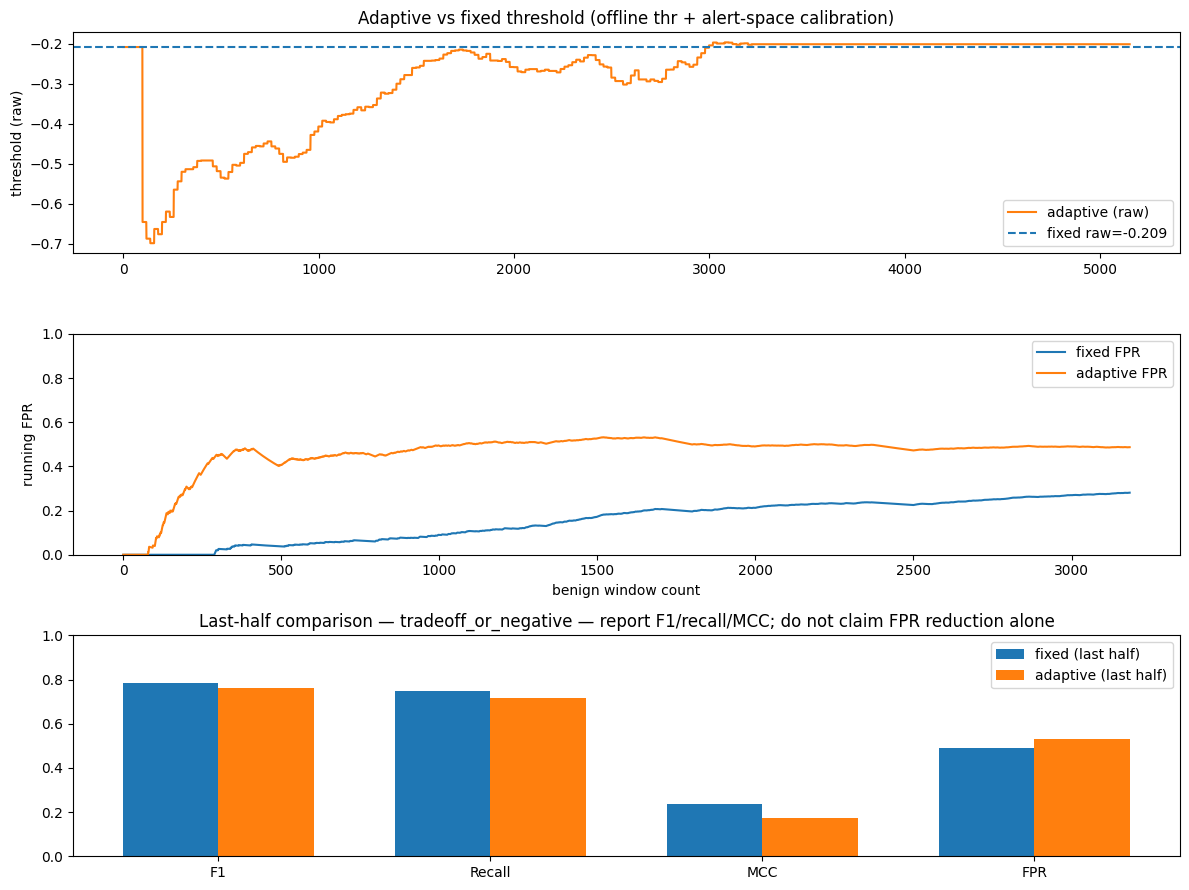

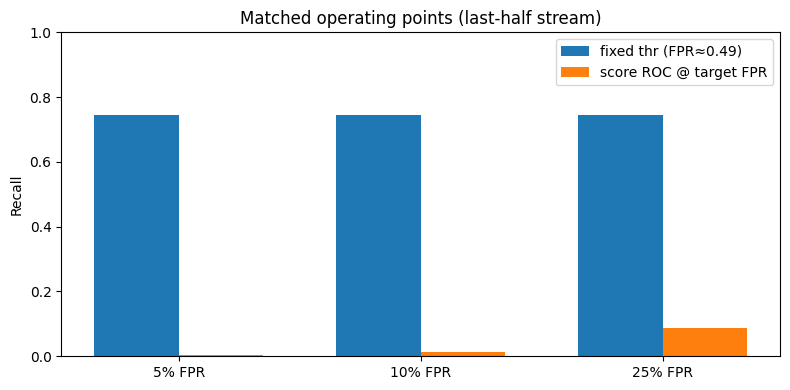

FPR first/last half — fixed: 0.2294/0.4905  adaptive: 0.4763/0.5302


In [10]:
# ---------------------------------------------------------------------------
# Phase 1 (docs/MODULE4_ADAPTIVE_THRESHOLD_IMPROVEMENT_PLAN.md): tune
# ADAPTIVE_TARGET_PCTL on VALIDATION data instead of the hand-picked guess.
# ---------------------------------------------------------------------------
pctl_sweep_result = None
if RUN_PCTL_SWEEP_ON_VAL:
    pctl_sweep_result = ev.sweep_adaptive_percentile_on_val(
        y_val, s_val, thr_fixed, ALERT_INVERT,
        timestamps_val=ts_val,
        percentiles=ADAPTIVE_PCTL_SWEEP_VALUES,
        buffer_size=BENIGN_BUFFER_SIZE,
        update_every=THRESHOLD_UPDATE_EVERY,
        recall_tol=ADAPTIVE_RECALL_TOL,
        f1_tol=ADAPTIVE_F1_TOL,
    )
    ADAPTIVE_TARGET_PCTL = pctl_sweep_result['selected_percentile']
    print('=== Phase 1: target_percentile sweep on VALIDATION data ===')
    print(f"  status: {pctl_sweep_result['status']}")
    for row in pctl_sweep_result['sweep_rows']:
        print(f"  pctl={row['target_percentile']:.0f}  "
              f"FPR={row['fpr_last_half']:.4f}  recall={row['recall_last_half']:.4f}  "
              f"F1={row['f1_last_half']:.4f}  fpr_red={row['fpr_reduction_last_half']:+.4f}  "
              f"recall_d={row['recall_delta_last_half']:+.4f}  f1_gain={row['f1_gain_last_half']:+.4f}")
    print(f"  SELECTED target_percentile = {ADAPTIVE_TARGET_PCTL:.1f}  "
          f"(max_abs_dev_from_fixed_alert={pctl_sweep_result['selected_row']['max_abs_dev_from_fixed_alert']:.4f})")
else:
    print(f'RUN_PCTL_SWEEP_ON_VAL=False -- using hand-set ADAPTIVE_TARGET_PCTL={ADAPTIVE_TARGET_PCTL}')

# ---------------------------------------------------------------------------
# Phase 2: tune threshold_smoothing on VALIDATION data, conditional on the
# Phase 1 winning percentile -- rather than a hand-picked value. (A local
# replay against the frozen test-set artifacts showed a hand-picked 0.7 can
# flip claim_ok from True to False once the percentile is properly tuned --
# exactly the failure mode Phase 1 fixed for target_percentile, so the same
# validation-only discipline applies here too.)
# ---------------------------------------------------------------------------
smoothing_sweep_result = None
if RUN_SMOOTHING_SWEEP_ON_VAL:
    smoothing_sweep_result = ev.sweep_adaptive_smoothing_on_val(
        y_val, s_val, thr_fixed, ALERT_INVERT,
        target_percentile=ADAPTIVE_TARGET_PCTL,
        timestamps_val=ts_val,
        smoothings=ADAPTIVE_SMOOTHING_SWEEP_VALUES,
        buffer_size=BENIGN_BUFFER_SIZE,
        update_every=THRESHOLD_UPDATE_EVERY,
        recall_tol=ADAPTIVE_RECALL_TOL,
        f1_tol=ADAPTIVE_F1_TOL,
        min_meaningful_gain=ADAPTIVE_SMOOTHING_MIN_GAIN,
    )
    ADAPTIVE_SMOOTHING = smoothing_sweep_result['selected_smoothing']
    print('=== Phase 2: threshold_smoothing sweep on VALIDATION data ===')
    print(f"  status: {smoothing_sweep_result['status']}")
    for row in smoothing_sweep_result['sweep_rows']:
        print(f"  smoothing={row['smoothing']:.2f}  FPR={row['fpr_last_half']:.4f}  "
              f"recall={row['recall_last_half']:.4f}  F1={row['f1_last_half']:.4f}  "
              f"fpr_red={row['fpr_reduction_last_half']:+.4f}")
    print(f"  SELECTED threshold_smoothing = {ADAPTIVE_SMOOTHING:.2f}")
else:
    print(f'RUN_SMOOTHING_SWEEP_ON_VAL=False -- using hand-set ADAPTIVE_SMOOTHING={ADAPTIVE_SMOOTHING}')

# Phase 4: derive the envelope half-width from the winning validation candidate
envelope_delta_alert = (
    pctl_sweep_result['selected_row']['max_abs_dev_from_fixed_alert']
    if (ADAPTIVE_USE_ENVELOPE and pctl_sweep_result is not None)
    else None
)
if envelope_delta_alert is not None:
    print(f'Phase 4: adaptive threshold will be clipped to fixed +/- {envelope_delta_alert:.4f} (alert space)')

# ---------------------------------------------------------------------------
# Phase 3: PSI-gated deviation -- only let the threshold move away from the
# fixed value once real drift is detected on the test stream. Computed once
# here (same rolling-PSI logic drift_aware_eval uses in Section 7) so both
# the primary evaluation below and the main stream loop agree.
# ---------------------------------------------------------------------------
drift_mask = None
if ADAPTIVE_PSI_GATE and drift_z is not None:
    drift_mask = np.zeros(n, dtype=bool)
    _flag = False
    for _t in range(n):
        if (_t + 1) % PSI_CHECK_EVERY == 0:
            _w0 = max(0, _t + 1 - PSI_CHECK_EVERY)
            _psis = psi_on_window_batch(X_stream[_w0:_t + 1], drift_z)
            _flag = bool(np.mean(_psis) > PSI_TRIGGER)
        drift_mask[_t] = _flag
    print(f'Phase 3: PSI-gated adaptation active for {drift_mask.mean()*100:.1f}% of stream steps')
elif ADAPTIVE_PSI_GATE:
    print('Phase 3: ADAPTIVE_PSI_GATE=True but drift_z unavailable -- gating disabled for this run')

sim = ev.AdaptiveThresholdSimulator(
    alpha=ADAPTIVE_ALPHA,
    buffer_size=BENIGN_BUFFER_SIZE,
    update_every=THRESHOLD_UPDATE_EVERY,
    invert=ALERT_INVERT,
    initial_threshold_raw=thr_fixed,
    estimator=ADAPTIVE_ESTIMATOR,
    target_percentile=ADAPTIVE_TARGET_PCTL,
    threshold_smoothing=ADAPTIVE_SMOOTHING,
    envelope_delta_alert=envelope_delta_alert,
)
stream_eval = ev.evaluate_stream_strategies(
    y_stream, s_stream, thr_fixed, ALERT_INVERT, sim, half_idx=mid,
    drift_mask=drift_mask,
)
thr_trace = stream_eval['threshold_trace_raw']

# Alpha sweep first (feeds matched-policy comparison)
alpha_sweep = None
if RUN_ALPHA_SWEEP:
    alpha_sweep = ev.sweep_adaptive_alpha(
        y_stream, s_stream, thr_fixed, ALERT_INVERT,
        alphas=ALPHA_SWEEP_VALUES,
        buffer_size=BENIGN_BUFFER_SIZE,
        update_every=THRESHOLD_UPDATE_EVERY,
        half_idx=mid,
        estimator=ADAPTIVE_ESTIMATOR,
        target_percentile=ADAPTIVE_TARGET_PCTL,
    )

# Task 2 — matched operating-point comparison (research primary)
matched_cmp = ev.matched_policy_comparison(
    y_stream, s_stream, thr_fixed, ALERT_INVERT,
    stream_eval=stream_eval,
    alpha_sweep=alpha_sweep,
    target_fprs=MATCHED_FPR_TARGETS,
    half_idx=mid,
)

adaptive_report = ev.report_to_jsonable({
    'score_invert_production': SCORE_INVERT,
    'alert_invert': ALERT_INVERT,
    'alert_space': True,
    'threshold_provenance': thr_info,
    'threshold_integrity': {
        'test_set': {k: thr_gate[k] for k in ('ok', 'pass_sane_fpr', 'pass_f1_match', 'pass_fpr_match', 'observed')},
        'stream_order': {k: stream_gate[k] for k in ('ok', 'pass_sane_fpr', 'observed')},
    },
    'stream_ordering': stream_meta,
    'alpha': ADAPTIVE_ALPHA,
    'buffer_size': BENIGN_BUFFER_SIZE,
    'update_every': THRESHOLD_UPDATE_EVERY,
    'estimator_config': {
        'estimator': ADAPTIVE_ESTIMATOR,
        'target_percentile': ADAPTIVE_TARGET_PCTL,
        'alpha': ADAPTIVE_ALPHA,
        'threshold_smoothing': ADAPTIVE_SMOOTHING,
        'envelope_delta_alert': envelope_delta_alert,
        'psi_gate_enabled': bool(ADAPTIVE_PSI_GATE and drift_mask is not None),
        'psi_gate_active_frac': (float(drift_mask.mean()) if drift_mask is not None else None),
        'pctl_sweep_status': (pctl_sweep_result['status'] if pctl_sweep_result is not None else None),
        'smoothing_sweep_status': (smoothing_sweep_result['status'] if smoothing_sweep_result is not None else None),
    },
    'fixed_global': stream_eval['fixed_global'],
    'adaptive_global': stream_eval['adaptive_global'],
    'fixed_first_half': stream_eval['fixed_first_half'],
    'fixed_last_half': stream_eval['fixed_last_half'],
    'adaptive_first_half': stream_eval['adaptive_first_half'],
    'adaptive_last_half': stream_eval['adaptive_last_half'],
    'fpr_reduction_last_half': stream_eval['fpr_reduction_last_half'],
    'f1_gain_last_half': stream_eval['f1_gain_last_half'],
    'recall_delta_last_half': stream_eval['recall_delta_last_half'],
    'matched_policy_comparison': matched_cmp,
})
for target_fpr in MATCHED_FPR_TARGETS:
    adaptive_report[f'matched_recall_at_fpr_{int(target_fpr*100)}'] = ev.matched_recall_at_fpr(
        y_stream, s_stream, thr_fixed, ALERT_INVERT, target_fpr,
    )

if alpha_sweep is not None:
    adaptive_report['alpha_sweep'] = alpha_sweep
    adaptive_report['best_alpha_by_f1_last_half'] = max(
        alpha_sweep, key=lambda r: r['f1_last_half'])['alpha']
    print('Alpha sweep (last half):')
    for row in alpha_sweep:
        print(f"  a={row['alpha']:.1f}  F1={row['f1_last_half']:.4f}  "
              f"FPR={row['fpr_last_half']:.4f}  recall={row['recall_last_half']:.4f}")

if pctl_sweep_result is not None:
    adaptive_report['pctl_sweep'] = pctl_sweep_result
if smoothing_sweep_result is not None:
    adaptive_report['smoothing_sweep'] = smoothing_sweep_result

print('=== Task 2 matched policy comparison ===')
print(f"  interpretation: {matched_cmp['interpretation']}")
print(f"  claim_ok (FPR↓ without recall/F1 collapse): "
      f"{matched_cmp['claim_adaptive_improves_without_recall_loss']}")
nat = matched_cmp['natural']
print(f"  natural last-half  fixed FPR={nat['fixed']['fpr']:.4f} F1={nat['fixed']['f1']:.4f} "
      f"recall={nat['fixed']['recall']:.4f}")
print(f"  natural last-half  adapt FPR={nat['adaptive']['fpr']:.4f} F1={nat['adaptive']['f1']:.4f} "
      f"recall={nat['adaptive']['recall']:.4f}")
print(f"  deltas: FPR_red={nat['fpr_reduction']:+.4f}  F1_gain={nat['f1_gain']:+.4f}  "
      f"recall_d={nat['recall_delta']:+.4f}")
am = matched_cmp.get('alpha_matched_to_fixed_fpr')
if am:
    print(f"  alpha-matched (a={am['alpha']:.1f}, fpr_gap={am['fpr_gap']:.4f}): "
          f"F1_delta={am['f1_delta']:+.4f}  recall_delta={am['recall_delta']:+.4f}")
for k, v in matched_cmp['roc_operating_points_last_half'].items():
    print(f"  ROC {k}: fixed_recall={v['fixed_recall']:.4f}@FPR={v['fixed_fpr']:.4f} | "
          f"roc_recall={v['roc_recall_at_target_fpr']:.4f} F1={v['roc_f1_at_target_fpr']:.4f}")

_keys = (
    'threshold_provenance', 'fixed_global', 'fixed_last_half', 'adaptive_last_half',
    'fpr_reduction_last_half', 'f1_gain_last_half', 'recall_delta_last_half',
    'matched_policy_comparison',
)
print(json.dumps({k: adaptive_report[k] for k in _keys if k in adaptive_report}, indent=2, default=str))
(OUT_DIR / 'adaptive_report.json').write_text(json.dumps(ev.to_jsonable(adaptive_report), indent=2))
(OUT_DIR / 'matched_policy_comparison.json').write_text(
    json.dumps(ev.to_jsonable(matched_cmp), indent=2))

benign_mask = y_stream == 0
benign_fixed_fp = ev.predict_alerts(s_stream[benign_mask], thr_fixed, ALERT_INVERT)
benign_adapt_fp = np.array([
    int(ev.to_alert_score(np.array([s_stream[t]]), ALERT_INVERT)[0]
        >= stream_eval['threshold_trace_alert'][t])
    for t in np.where(benign_mask)[0]
], dtype=np.float32)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(thr_trace, color='C1', label='adaptive (raw)')
axes[0].axhline(thr_fixed, color='C0', ls='--', label=f'fixed raw={thr_fixed:.3f}')
axes[0].set_ylabel('threshold (raw)'); axes[0].legend()
axes[0].set_title('Adaptive vs fixed threshold (offline thr + alert-space calibration)')

axes[1].plot(np.cumsum(benign_fixed_fp) / np.arange(1, len(benign_fixed_fp) + 1), label='fixed FPR')
axes[1].plot(np.cumsum(benign_adapt_fp) / np.arange(1, len(benign_adapt_fp) + 1), label='adaptive FPR')
axes[1].set_xlabel('benign window count'); axes[1].set_ylabel('running FPR'); axes[1].legend()
axes[1].set_ylim(0, 1)

labels_bar = ['F1', 'Recall', 'MCC', 'FPR']
fixed_last = stream_eval['fixed_last_half']
adapt_last = stream_eval['adaptive_last_half']
x = np.arange(len(labels_bar)); w = 0.35
fixed_vals = [fixed_last['f1'], fixed_last['recall'], fixed_last['mcc'], fixed_last['fpr']]
adapt_vals = [adapt_last['f1'], adapt_last['recall'], adapt_last['mcc'], adapt_last['fpr']]
axes[2].bar(x - w/2, fixed_vals, w, label='fixed (last half)')
axes[2].bar(x + w/2, adapt_vals, w, label='adaptive (last half)')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels_bar)
axes[2].set_ylim(0, 1); axes[2].legend()
axes[2].set_title(f'Last-half comparison — {matched_cmp["interpretation"]}')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_adaptive_threshold.png', dpi=300)
plt.savefig(OUT_DIR / 'adaptive_threshold.png', dpi=140)
plt.show()

# Matched-FPR bar chart (Task 2 figure)
fig2, ax2 = plt.subplots(figsize=(8, 4))
ops = matched_cmp['roc_operating_points_last_half']
targets = list(MATCHED_FPR_TARGETS)
roc_recalls = [ops[f'fpr_{int(t*100)}']['roc_recall_at_target_fpr'] for t in targets]
fixed_recalls = [ops[f'fpr_{int(t*100)}']['fixed_recall'] for t in targets]
xpos = np.arange(len(targets)); w = 0.35
ax2.bar(xpos - w/2, fixed_recalls, w, label=f'fixed thr (FPR≈{fixed_last["fpr"]:.2f})')
ax2.bar(xpos + w/2, roc_recalls, w, label='score ROC @ target FPR')
ax2.set_xticks(xpos); ax2.set_xticklabels([f'{int(t*100)}% FPR' for t in targets])
ax2.set_ylabel('Recall'); ax2.set_ylim(0, 1)
ax2.set_title('Matched operating points (last-half stream)')
ax2.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07b_matched_operating_points.png', dpi=300)
plt.savefig(OUT_DIR / 'matched_operating_points.png', dpi=140)
plt.show()

fa_first = stream_eval['adaptive_first_half']['fpr']
fa_last  = stream_eval['adaptive_last_half']['fpr']
ff_first = stream_eval['fixed_first_half']['fpr']
ff_last  = stream_eval['fixed_last_half']['fpr']
print(f'FPR first/last half — fixed: {ff_first:.4f}/{ff_last:.4f}  '
      f'adaptive: {fa_first:.4f}/{fa_last:.4f}')


## 6. Incremental fine-tune (WBS §2.2)

**Interpretation:** Benign-only MSE fine-tune may degrade drift-slice AUC (catastrophic forgetting). A negative Δ is a valid research finding — report transparently in Discussion, not as a success claim.

Drift slice: (1546, 10, 163)  benign for FT: 200  (source=stable_slice_fallback)
AUC drift slice BEFORE fine-tune: nan
NOTE: drift slice is single-class -- ROC-AUC undefined, reporting NaN rather than a misleading number.
AUC drift slice AFTER  fine-tune: nan  delta=+nan


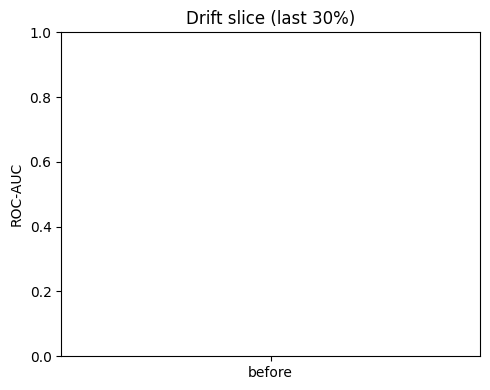

In [11]:
from copy import deepcopy
from torch import optim

def fine_tune_on_recent(m, benign_windows, steps=FINETUNE_STEPS, lr=FINETUNE_LR):
    m = deepcopy(m)
    m.train()
    opt = optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    loader = DataLoader(TensorDataset(torch.from_numpy(benign_windows).float()),
                        batch_size=BATCH_SIZE, shuffle=True)
    for step in range(steps):
        for (xb,) in loader:
            xb = xb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = F.mse_loss(m(xb), xb)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            break  # one mini-batch per step
    m.eval()
    return m

X_drift = X_stream[split_idx:]
y_drift = y_stream[split_idx:]
benign_drift_idx = np.where(y_drift == 0)[0]

if len(benign_drift_idx) > 0:
    benign_pick = benign_drift_idx[-FINETUNE_BENIGN_N:] if len(benign_drift_idx) >= FINETUNE_BENIGN_N else benign_drift_idx
    X_ft = X_drift[benign_pick]
    ft_source = 'drift_slice'
else:
    # Real timestamp ordering can put the drift slice at 100% attack traffic
    # (observed on this dataset) -- fall back to the most recent benign
    # windows from the stable slice so fine-tuning has something to train on.
    X_stable = X_stream[:split_idx]
    y_stable = y_stream[:split_idx]
    benign_stable_idx = np.where(y_stable == 0)[0]
    benign_pick = benign_stable_idx[-FINETUNE_BENIGN_N:] if len(benign_stable_idx) >= FINETUNE_BENIGN_N else benign_stable_idx
    X_ft = X_stable[benign_pick]
    ft_source = 'stable_slice_fallback'

print(f'Drift slice: {X_drift.shape}  benign for FT: {len(X_ft)}  (source={ft_source})')

s_before = compute_scores(X_drift, model, feat_std)
auc_before = roc_auc_score(y_drift, s_before) if len(np.unique(y_drift)) > 1 else float('nan')
print(f'AUC drift slice BEFORE fine-tune: {auc_before:.4f}')
if len(np.unique(y_drift)) <= 1:
    print('NOTE: drift slice is single-class -- ROC-AUC undefined, reporting NaN rather than a misleading number.')

if len(X_ft) > 0:
    model_ft = fine_tune_on_recent(model, X_ft, steps=FINETUNE_STEPS, lr=FINETUNE_LR)
    s_after = compute_scores(X_drift, model_ft, feat_std)
    auc_after = roc_auc_score(y_drift, s_after) if len(np.unique(y_drift)) > 1 else float('nan')
    print(f'AUC drift slice AFTER  fine-tune: {auc_after:.4f}  delta={auc_after-auc_before:+.4f}')
else:
    print('WARNING: no benign windows available anywhere (drift slice or stable slice) -- skipping fine-tune.')
    model_ft = None
    auc_after = float('nan')

finetune_report = {
    'drift_slice_frac': DRIFT_SLICE_FRAC,
    'stream_ordering': stream_meta['ordering_mode'],
    'finetune_benign_source': ft_source,
    'finetune_benign_n': int(len(X_ft)),
    'finetune_steps': FINETUNE_STEPS,
    'finetune_lr': FINETUNE_LR,
    'auc_before': float(auc_before),
    'auc_after': float(auc_after),
    'auc_delta': float(auc_after - auc_before),
    'interpretation': (
        'negative_delta_expected' if auc_after < auc_before else 'positive_delta'
    ),
    'catastrophic_forgetting_note': (
        'Benign-only MSE fine-tune may collapse attack separation learned offline. '
        'See thesis_drift_aware_notes.md §4.'
    ),
}
(OUT_DIR / 'finetune_report.json').write_text(json.dumps(ev.to_jsonable(finetune_report), indent=2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['before', 'after'], [auc_before, auc_after], color=['C0', 'C2'])
ax.set_ylim(0, 1); ax.set_ylabel('ROC-AUC'); ax.set_title(f'Drift slice (last {int(DRIFT_SLICE_FRAC*100)}%)')
for i, v in enumerate([auc_before, auc_after]):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_finetune_auc.png', dpi=300)
plt.savefig(OUT_DIR / 'finetune_auc.png', dpi=140)
plt.show()

## 7. Simulated streaming loop (WBS §2.3)

**Terminology:** *Simulated streaming replay* — not live deployment. Order = timestamp (if in npz) else container lexsort. PSI triggers are illustrative.

Logged 5153 steps (timestamp order)
  -> /kaggle/working/drift_aware/drift_aware_log.csv


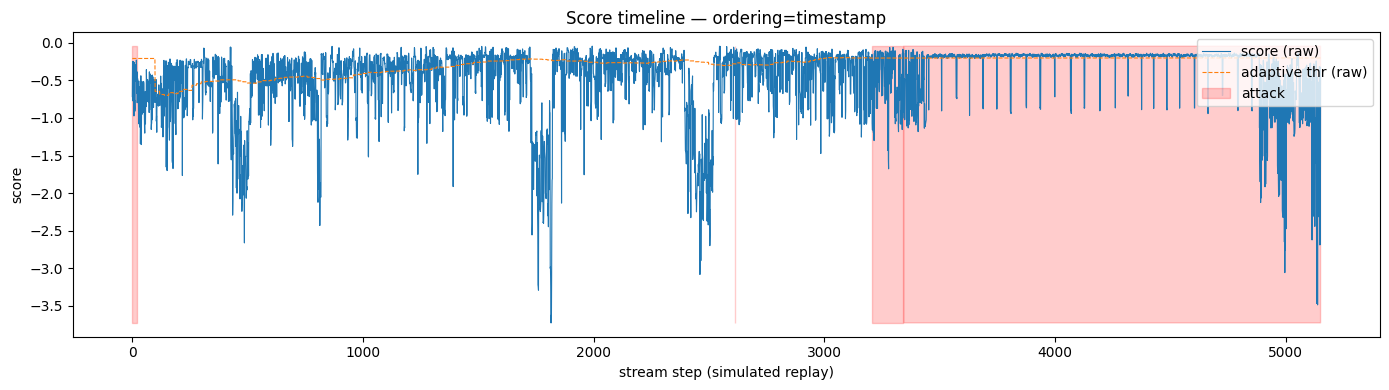

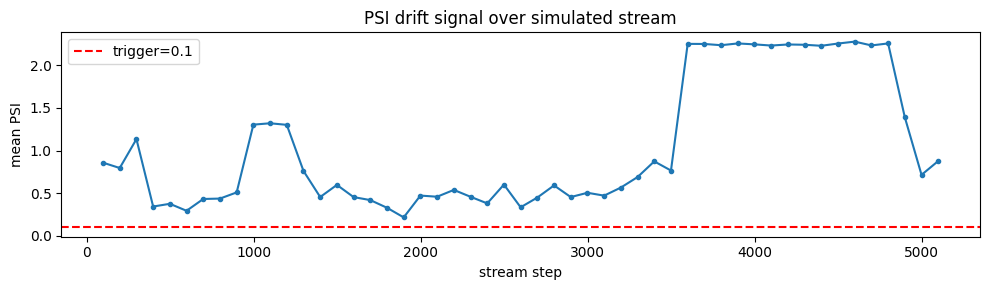

In [12]:
def drift_aware_eval(X_ord, y_ord, s_ord, model_base, drift_baseline=None,
                     model_ft=None, fixed_thr_raw=thr_fixed, invert=ALERT_INVERT):
    """Simulated streaming orchestration: score -> benign buffer -> adaptive thr -> PSI -> optional FT.

    Phase 2/3/4 (docs/MODULE4_ADAPTIVE_THRESHOLD_IMPROVEMENT_PLAN.md): the
    simulator is constructed with the same smoothing/envelope settings as the
    primary Section 5 evaluation, and drift_active is recomputed every step
    from the same rolling-PSI check already used for the fine-tune trigger,
    so this log's threshold trace matches what Section 5 reports.
    """
    m = model_base
    ft_done = False
    sim = ev.AdaptiveThresholdSimulator(
        alpha=ADAPTIVE_ALPHA,
        buffer_size=BENIGN_BUFFER_SIZE,
        update_every=THRESHOLD_UPDATE_EVERY,
        invert=invert,
        initial_threshold_raw=fixed_thr_raw,
        estimator=ADAPTIVE_ESTIMATOR,
        target_percentile=ADAPTIVE_TARGET_PCTL,
        threshold_smoothing=ADAPTIVE_SMOOTHING,
        envelope_delta_alert=globals().get('envelope_delta_alert'),
    )
    logs = []
    drift_active = False  # Phase 3: start "calm" until the first PSI reading says otherwise
    for t in range(len(X_ord)):
        xw = X_ord[t:t+1]
        if model_ft is not None and ft_done and t >= split_idx:
            score = float(compute_scores(xw, m, feat_std)[0])
        else:
            score = float(s_ord[t])
        label = int(y_ord[t])
        mean_psi = np.nan
        if (t + 1) % PSI_CHECK_EVERY == 0 and drift_baseline is not None:
            w0 = max(0, t + 1 - PSI_CHECK_EVERY)
            psis = psi_on_window_batch(X_ord[w0:t+1], drift_baseline)
            mean_psi = float(np.mean(psis))
            drift_active = bool(mean_psi > PSI_TRIGGER)
            if (not ft_done) and drift_active and model_ft is not None and t >= split_idx:
                m = model_ft
                ft_done = True
        thr_raw = sim.observe(score, label, t, drift_active=(drift_active if ADAPTIVE_PSI_GATE else True))
        alert = int(ev.to_alert_score(np.array([score]), invert)[0]
                    >= ev.alert_threshold_from_raw(thr_raw, invert))
        logs.append({
            't': t,
            'score': score,
            'threshold_raw': thr_raw,
            'threshold_alert': ev.alert_threshold_from_raw(thr_raw, invert),
            'alert': alert,
            'label': label,
            'mean_psi': mean_psi,
            'drift_active': int(drift_active if ADAPTIVE_PSI_GATE else True),
            'finetuned': int(ft_done),
            'stream_ordering': stream_meta['ordering_mode'],
        })
    return logs

# Ensure drift baseline + stream arrays exist (if the load cell was skipped/partial)
import numpy as np

if "drift_z" not in globals() or drift_z is None:
    _dp = globals().get("DRIFT_PATH") or (DATA_DIR / "drift_baseline_vnext.npz")
    _dp = Path(_dp)
    if not _dp.is_file():
        _found = kaggle_find(_dp.name)
        if _found is not None:
            _dp = _found
    if _dp.is_file():
        drift_z = np.load(_dp, allow_pickle=True)
        print(f"Loaded drift_z from {_dp} ({drift_z['mean'].shape[0]} features)")
    else:
        drift_z = None
        print(f"WARN: no drift baseline at {_dp} -- PSI uses None (feature-mean proxy path)")

if "X_stream" not in globals():
    raise NameError(
        "X_stream not defined — run the evaluation/setup cell that builds "
        "X_stream, y_stream, s_stream (threshold integrity + stream order) first."
    )
if "model_ft" not in globals():
    model_ft = None
    print("model_ft undefined — using None (no fine-tune model)")

logs = drift_aware_eval(X_stream, y_stream, s_stream, model, drift_z, model_ft)

import pandas as pd
df_log = pd.DataFrame(logs)
df_log.to_csv(OUT_DIR / 'drift_aware_log.csv', index=False)
(OUT_DIR / 'drift_aware_log.json').write_text(df_log.to_json(orient='records', indent=2))
print(f'Logged {len(df_log)} steps ({stream_meta["ordering_mode"]} order)')
print(f'  -> {OUT_DIR / "drift_aware_log.csv"}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_log['score'].values, lw=0.8, label='score (raw)')
ax.plot(df_log['threshold_raw'].values, lw=0.8, ls='--', label='adaptive thr (raw)')
atk = df_log['label'].values == 1
ax.fill_between(np.arange(len(df_log)), df_log['score'].min(), df_log['score'].max(),
                where=atk, alpha=0.2, color='red', label='attack')
ax.set_xlabel('stream step (simulated replay)'); ax.set_ylabel('score'); ax.legend(loc='upper right')
ax.set_title(f'Score timeline — ordering={stream_meta["ordering_mode"]}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_score_timeline.png', dpi=300)
plt.savefig(OUT_DIR / 'score_timeline.png', dpi=140)
plt.show()

psi_rows = df_log[df_log['mean_psi'].notna()]
if len(psi_rows):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(psi_rows['t'], psi_rows['mean_psi'], marker='o', ms=3)
    ax.axhline(PSI_TRIGGER, color='r', ls='--', label=f'trigger={PSI_TRIGGER}')
    ax.set_xlabel('stream step'); ax.set_ylabel('mean PSI'); ax.legend()
    ax.set_title('PSI drift signal over simulated stream')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig08_psi_timeline.png', dpi=300)
    plt.savefig(OUT_DIR / 'psi_timeline.png', dpi=140)
    plt.show()


## 8. Isolation Forest baseline (WBS §3.1)

Benign-only training, mean+max temporal pooling, `contamination='auto'`, validation score-direction calibration. Matches AE training paradigm.

In [13]:
if_baseline = ev.IsolationForestBaseline(
    n_estimators=200,
    contamination='auto',
    random_state=SEED,
    pool_mode='mean_max',
)
print(f'Fitting IsolationForest (benign-only, pool=mean_max) on {X_train.shape[0]} windows ...')
if_baseline.fit(X_train)  # X_train is benign-only in windows_vnext.npz
if_result = if_baseline.evaluate(X_val, y_val, X_test, y_test)
r_if = if_result['metrics']
thr_if = if_result['threshold']

print(f'IsolationForest fit: n={if_result["fit_n_samples"]}  time={if_result["fit_time_s"]:.1f}s')
print(f'  val ROC={if_result["val_roc_auc"]:.4f}  test ROC={if_result["test_roc_auc"]:.4f}')
print(f'  score_inverted={if_result["score_inverted"]}')
print(json.dumps({k: round(v, 4) if isinstance(v, float) else v for k, v in r_if.items()}, indent=2))

# Sensitivity: flattened benign-only (thesis footnote if still weak)
if_flat = ev.IsolationForestBaseline(pool_mode='flatten', contamination='auto', random_state=SEED)
if_flat.fit(X_train)
if_flat_result = if_flat.evaluate(X_val, y_val, X_test, y_test)

baseline_table = {
    'vNext_default': metrics['test_default']['f1_optimal'],
    'vNext_hpo': metrics.get('test_hpo', {}),
    'isolation_forest_mean_max': {
        'metrics': r_if,
        'meta': {k: if_result[k] for k in (
            'pool_mode', 'contamination', 'fit_n_samples', 'fit_time_s', 'score_inverted',
        )},
    },
    'isolation_forest_flatten_sensitivity': {
        'metrics': if_flat_result['metrics'],
        'meta': {k: if_flat_result[k] for k in (
            'pool_mode', 'contamination', 'fit_n_samples', 'score_inverted',
        )},
    },
}
(OUT_DIR / 'baseline_comparison.json').write_text(json.dumps(ev.to_jsonable(baseline_table), indent=2))
print('Saved ->', OUT_DIR / 'baseline_comparison.json')

Fitting IsolationForest (benign-only, pool=mean_max) on 16795 windows ...
IsolationForest fit: n=16795  time=0.4s
  val ROC=0.6931  test ROC=0.6741
  score_inverted=False
{
  "roc_auc": 0.6741,
  "pr_auc": 0.4464,
  "f1": 0.7104,
  "precision": 0.6266,
  "recall": 0.8201,
  "mcc": 0.5034,
  "bal_acc": 0.759,
  "fpr": 0.302,
  "fnr": 0.1799,
  "thr_raw": -0.0495,
  "thr_alert": -0.0495
}
Saved -> /kaggle/working/drift_aware/baseline_comparison.json


## 9. Ablation table (WBS §3.2) — from saved runs + this notebook

In [14]:
# Task 8 — Ablation tables (offline vs stream; never mix metrics)
ABLATION_METRICS_PATH = RUN_DIR / 'metrics_ablation_vnext.json'
ABLATION_RETRAIN_CSV = RUN_DIR / 'ablation_retrain_table.csv'
ablation_retrain = {}
if ABLATION_METRICS_PATH.is_file():
    ablation_retrain = json.loads(ABLATION_METRICS_PATH.read_text())
    print(f'Loaded retrain ablations: {list(ablation_retrain.keys())}')
else:
    print(f'No retrain ablations at {ABLATION_METRICS_PATH} — run mdc_model_vNext.ipynb §18b')

fixed_stream = ev.classification_metrics(y_stream, s_stream, thr_fixed, ALERT_INVERT)
adapt_last = stream_eval['adaptive_last_half']
default_roc = float(metrics['test_default']['f1_optimal']['roc_auc'])
default_f1 = float(metrics['test_default']['f1_optimal']['f1'])
default_mcc = float(metrics['test_default']['f1_optimal']['mcc'])

# Table A — offline detector configs (comparable ROC/F1/MCC only)
abl_offline = [
    {'config': 'Full vNext HPO', 'roc_auc': metrics.get('test_hpo', {}).get('roc_auc', 0.8138),
     'mcc': metrics.get('test_hpo', {}).get('mcc', 0.626),
     'f1': metrics.get('test_hpo', {}).get('f1', 0.774),
     'delta_roc_vs_default': float(metrics.get('test_hpo', {}).get('roc_auc', 0.8138) - default_roc),
     'source': 'metrics_vnext.json'},
    {'config': 'vNext default (AUC-best)', 'roc_auc': default_roc,
     'mcc': default_mcc, 'f1': default_f1,
     'delta_roc_vs_default': 0.0, 'source': 'metrics_vnext.json'},
    {'config': 'Multi-seed mean', 'roc_auc': metrics['multi_seed']['roc_auc']['mean'],
     'mcc': metrics['multi_seed']['mcc']['mean'],
     'delta_roc_vs_default': float(metrics['multi_seed']['roc_auc']['mean'] - default_roc),
     'source': 'metrics_vnext.json'},
    {'config': 'Isolation Forest (mean+max)', 'roc_auc': r_if['roc_auc'],
     'mcc': r_if['mcc'], 'f1': r_if['f1'],
     'delta_roc_vs_default': float(r_if['roc_auc'] - default_roc), 'source': '§8'},
]
for name, payload in ablation_retrain.items():
    t = payload.get('test', {})
    d = payload.get('delta_vs_default', {})
    abl_offline.append({
        'config': f'Retrain: {name}',
        'roc_auc': t.get('roc_auc'),
        'mcc': t.get('mcc'),
        'f1': t.get('f1'),
        'delta_roc_vs_default': d.get('roc_auc', (t.get('roc_auc') or default_roc) - default_roc),
        'delta_f1_vs_default': d.get('f1'),
        'thesis_usable': payload.get('protocol', {}).get('thesis_usable', True),
        'source': 'mdc_model_vNext §18b',
    })

# Table B — streaming monitoring policies (same order + thr provenance)
abl_stream = [
    {'config': 'Fixed threshold (stream)', 'roc_auc': fixed_stream['roc_auc'],
     'f1': fixed_stream['f1'], 'recall': fixed_stream['recall'], 'mcc': fixed_stream['mcc'],
     'fpr': fixed_stream['fpr'],
     'fpr_last_half': stream_eval['fixed_last_half']['fpr'],
     'f1_last_half': stream_eval['fixed_last_half']['f1'],
     'recall_last_half': stream_eval['fixed_last_half']['recall'],
     'thr_raw': thr_fixed, 'source': '§5 stream (offline thr)'},
    {'config': 'Adaptive threshold (stream)',
     'f1_last_half': adapt_last['f1'], 'recall_last_half': adapt_last['recall'],
     'mcc_last_half': adapt_last['mcc'], 'fpr_last_half': adapt_last['fpr'],
     'f1_gain_last_half': stream_eval['f1_gain_last_half'],
     'recall_delta_last_half': stream_eval['recall_delta_last_half'],
     'fpr_reduction_last_half': stream_eval['fpr_reduction_last_half'],
     'claim_ok': matched_cmp['claim_adaptive_improves_without_recall_loss'],
     'interpretation': matched_cmp['interpretation'],
     'source': '§5 adaptive'},
    {'config': 'Fine-tune on drift slice', 'auc_before': auc_before, 'auc_after': auc_after,
     'auc_delta': auc_after - auc_before, 'source': '§6 fine-tune'},
]

abl_offline_df = pd.DataFrame(abl_offline)
abl_stream_df = pd.DataFrame(abl_stream)
print('=== Table A: Offline detector configs (Task 8) ===')
print(abl_offline_df.to_string(index=False))
print('\n=== Table B: Streaming monitoring policies (Task 8) ===')
print(abl_stream_df.to_string(index=False))

abl_offline_df.to_csv(OUT_DIR / 'ablation_table_offline.csv', index=False)
abl_stream_df.to_csv(OUT_DIR / 'ablation_table_stream.csv', index=False)
abl_df = pd.concat([abl_offline_df, abl_stream_df], ignore_index=True, sort=False)
abl_df.to_csv(OUT_DIR / 'ablation_table.csv', index=False)

# Markdown tables for thesis paste-in
def _md_table(df, cols):
    use = [c for c in cols if c in df.columns]
    lines = ['| ' + ' | '.join(use) + ' |',
             '| ' + ' | '.join(['---'] * len(use)) + ' |']
    for _, row in df.iterrows():
        cells = []
        for c in use:
            v = row[c]
            if isinstance(v, float):
                cells.append(f'{v:.4f}' if np.isfinite(v) else '')
            else:
                cells.append('' if pd.isna(v) else str(v))
        lines.append('| ' + ' | '.join(cells) + ' |')
    return '\n'.join(lines)

md_a = _md_table(abl_offline_df, ['config', 'roc_auc', 'f1', 'mcc', 'delta_roc_vs_default', 'source'])
md_b = _md_table(abl_stream_df, ['config', 'f1_last_half', 'recall_last_half', 'fpr_last_half',
                                 'f1_gain_last_half', 'interpretation', 'source'])
md_doc = (
    '# Ablation tables (auto-exported)\n\n'
    '## Table A — Offline detector configs\n\n' + md_a + '\n\n'
    '## Table B — Streaming monitoring policies\n\n' + md_b + '\n\n'
    '**Rule:** Do not compare offline ROC-AUC to stream FPR in the same sentence '
    'without stating they are different evaluation protocols.\n'
)
(OUT_DIR / 'ablation_tables.md').write_text(md_doc, encoding='utf-8')
print('Saved ->', OUT_DIR / 'ablation_table_offline.csv')
print('Saved ->', OUT_DIR / 'ablation_table_stream.csv')
print('Saved ->', OUT_DIR / 'ablation_tables.md')
if ABLATION_RETRAIN_CSV.is_file():
    print(f'Also available: {ABLATION_RETRAIN_CSV}')


No retrain ablations at /kaggle/working/runs/metrics_ablation_vnext.json — run mdc_model_vNext.ipynb §18b
=== Table A: Offline detector configs (Task 8) ===
                     config  roc_auc      mcc       f1  delta_roc_vs_default             source
             Full vNext HPO 0.844607 0.708034 0.803018              0.167915 metrics_vnext.json
   vNext default (AUC-best) 0.676693 0.446129 0.673309              0.000000 metrics_vnext.json
            Multi-seed mean 0.726114 0.559244      NaN              0.049421 metrics_vnext.json
Isolation Forest (mean+max) 0.674149 0.503425 0.710387             -0.002544                 §8

=== Table B: Streaming monitoring policies (Task 8) ===
                     config  roc_auc       f1   recall      mcc      fpr  fpr_last_half  f1_last_half  recall_last_half   thr_raw                  source  mcc_last_half  f1_gain_last_half  recall_delta_last_half  fpr_reduction_last_half claim_ok                                                             

## 10. Bootstrap CI + TPR@FPR + latency (WBS §3.3)

In [15]:
def bootstrap_ci(y, s, metric_fn, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2: continue
        vals.append(metric_fn(y[idx], s[idx]))
    vals = np.array(vals)
    return float(np.mean(vals)), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

roc_m, roc_lo, roc_hi = bootstrap_ci(y_test, s_test, roc_auc_score)
mcc_m, mcc_lo, mcc_hi = bootstrap_ci(y_test, s_test,
    lambda y, s: matthews_corrcoef(y, ev.predict_alerts(s, thr_fixed, ALERT_INVERT)))
print(f'ROC-AUC bootstrap 95% CI: {roc_m:.4f} [{roc_lo:.4f}, {roc_hi:.4f}]')
print(f'MCC bootstrap 95% CI:     {mcc_m:.4f} [{mcc_lo:.4f}, {mcc_hi:.4f}]')

fpr, tpr, _ = roc_curve(y_test, s_test)
for target in [0.05, 0.10, 0.25]:
    i = np.searchsorted(fpr, target)
    i = min(i, len(tpr)-1)
    print(f'TPR @ FPR={int(target*100):>2}% : {tpr[i]:.4f}')

# Latency benchmark (CPU)
model_cpu = model.to('cpu')
xw = torch.from_numpy(X_test[:1]).float()
for _ in range(10): _ = model_cpu(xw)
times = []
for _ in range(200):
    t0 = time.perf_counter()
    with torch.no_grad(): _ = model_cpu(xw)
    times.append((time.perf_counter() - t0) * 1000)
lat_ms = float(np.median(times))
print(f'Inference latency (CPU, 1 window): {lat_ms:.2f} ms  target<100ms')
model.to(device)

stats_report = {
    'bootstrap_roc_auc': {'mean': roc_m, 'ci_lo': roc_lo, 'ci_hi': roc_hi},
    'bootstrap_mcc': {'mean': mcc_m, 'ci_lo': mcc_lo, 'ci_hi': mcc_hi},
    'latency_ms_cpu_median': lat_ms,
}
(OUT_DIR / 'stats_report.json').write_text(json.dumps(ev.to_jsonable(stats_report), indent=2))


ROC-AUC bootstrap 95% CI: 0.6768 [0.6613, 0.6930]
MCC bootstrap 95% CI:     0.4461 [0.4221, 0.4735]
TPR @ FPR= 5% : 0.0041
TPR @ FPR=10% : 0.0229
TPR @ FPR=25% : 0.6748
Inference latency (CPU, 1 window): 1.60 ms  target<100ms


299

## 11. Thesis figure package — copy from RUN_DIR + new plots

Copied eval_vnext.png


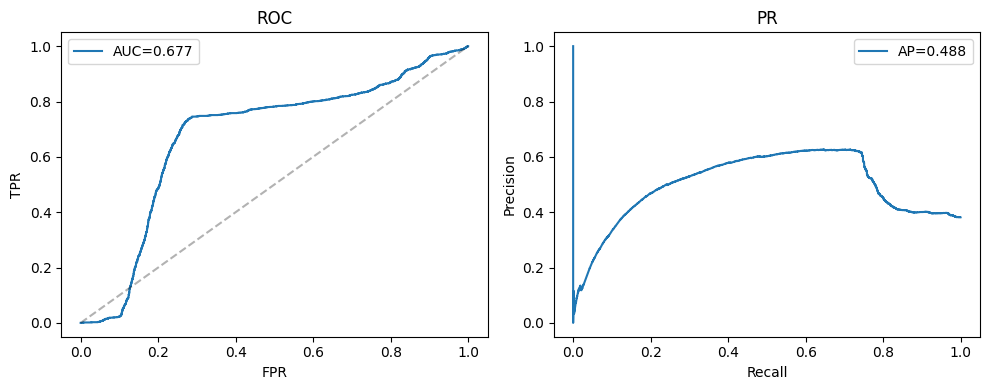


=== DONE ===
Outputs: /kaggle/working/drift_aware
Thesis figures (300 dpi): /kaggle/working/drift_aware/thesis_figures_300dpi
  eval_vnext_from_run.png
  fig05_roc_pr.png
  fig06_score_timeline.png
  fig07_adaptive_threshold.png
  fig07b_matched_operating_points.png
  fig08_psi_timeline.png
  fig10_finetune_auc.png


In [16]:
COPY_FROM_RUN = [
    'eval_vnext.png', 'eval_per_attack_type.png', 'eval_per_attack_roc.png',
]
for name in COPY_FROM_RUN:
    src = RUN_DIR / name
    if src.is_file():
        shutil.copy2(src, FIG_DIR / name.replace('.png', '_from_run.png'))
        print(f'Copied {name}')

# ROC + PR from saved scores @ 300 dpi
from sklearn.metrics import precision_recall_curve, auc as sk_auc
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, s_test):.3f}')
ax[0].plot([0,1],[0,1],'k--',alpha=0.3); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ax[0].set_title('ROC'); ax[0].legend()
prec, rec, _ = precision_recall_curve(y_test, s_test)
ax[1].plot(rec, prec, label=f'AP={average_precision_score(y_test, s_test):.3f}')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision'); ax[1].set_title('PR'); ax[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_roc_pr.png', dpi=300)
plt.show()

summary = {
    'created_at': datetime.now(timezone.utc).isoformat(),
    'version': 'drift_aware_v2',
    'stream_ordering': stream_meta,
    'adaptive': adaptive_report,
    'threshold_provenance': thr_info,
    'alert_invert': ALERT_INVERT,
    'matched_policy': matched_cmp,
    'tasks_1_3': {
        'thr_source': thr_info['source'],
        'thr_fixed': thr_fixed,
        'integrity_ok': thr_gate['ok'] and stream_gate['ok'],
        'claim_adaptive_ok': matched_cmp['claim_adaptive_improves_without_recall_loss'],
        'interpretation': matched_cmp['interpretation'],
        'stream_ordering': stream_meta['ordering_mode'],
    },
    'finetune': finetune_report,
    'baseline': baseline_table,
    'stats': stats_report,
    'figures_dir': str(FIG_DIR),
    'headline_metrics': {
        'default_test_roc': metrics['test_default']['f1_optimal']['roc_auc'],
        'multi_seed_roc_mean': metrics['multi_seed']['roc_auc']['mean'],
        'hpo_test_roc': metrics.get('test_hpo', {}).get('roc_auc'),
    },
}
summary_json = ev.to_jsonable(summary)
(OUT_DIR / 'drift_aware_summary.json').write_text(json.dumps(summary_json, indent=2))
print('\n=== DONE ===')
print(f'Outputs: {OUT_DIR}')
print(f'Thesis figures (300 dpi): {FIG_DIR}')
for f in sorted(FIG_DIR.glob('*')):
    print(f'  {f.name}')


## 11b. Tasks 3–4 — Validation gates + freeze protocol

### Gates (must all pass before freeze)

| Gate | Expected |
|------|----------|
| `THRESHOLD INTEGRITY: PASS` | Printed in §4 |
| `thr_fixed` | ≈ **−0.1434** (from metrics, not −0.0923) |
| Fixed stream FPR | **≪ 0.50** (typically ~0.14 offline) |
| Fixed stream F1 | ≈ **0.74** offline / similar on stream |
| `ALERT_INVERT` | **False** |
| `matched_policy_comparison.json` | Written |
| Claim gate | Use `claim_ok` / `interpretation` — never cite v1 `fpr_reduction=0.92` |
| Figures | `fig07_adaptive_threshold.png` + `fig07b_matched_operating_points.png` |
| Ordering | Prefer `timestamp` (Task 6); `container_lexsort` only with limitation note |

### Freeze (Task 4)

1. Run the next code cell — writes `freeze_manifest_v2.json` and checks required artifacts.
2. Download this executed notebook → save as `notebook/run/mdc_drift_aware_output_v2.ipynb`.
3. Keep `mdc_drift_aware_output.ipynb` as **LEGACY** (invalid adaptive comparison).
4. Copy `drift_aware/` outputs into the thesis evidence pack.


In [17]:
# Task 4 — Freeze manifest (thesis evidence pack)
REQUIRED_ARTIFACTS = [
    'adaptive_report.json',
    'matched_policy_comparison.json',
    'finetune_report.json',
    'baseline_comparison.json',
    'ablation_table.csv',
    'ablation_table_offline.csv',
    'ablation_table_stream.csv',
    'stats_report.json',
    'drift_aware_summary.json',
    'drift_aware_log.csv',
    'adaptive_threshold.png',
    'matched_operating_points.png',
    'finetune_auc.png',
    'score_timeline.png',
]
REQUIRED_FIGURES = [
    'fig07_adaptive_threshold.png',
    'fig07b_matched_operating_points.png',
    'fig10_finetune_auc.png',
    'fig06_score_timeline.png',
    'fig05_roc_pr.png',
]

missing_art = [n for n in REQUIRED_ARTIFACTS if not (OUT_DIR / n).is_file()]
missing_fig = [n for n in REQUIRED_FIGURES if not (FIG_DIR / n).is_file()]

_integrity_ok = bool(globals().get('thr_gate', {}).get('ok')) and bool(globals().get('stream_gate', {}).get('ok'))
_claim_ok = bool(globals().get('matched_cmp', {}).get('claim_adaptive_improves_without_recall_loss', False))
_thr = float(globals().get('thr_fixed', float('nan')))
_order = globals().get('stream_meta', {}).get('ordering_mode', 'unknown')
_alert_inv = bool(globals().get('ALERT_INVERT', True))
_fixed_fpr = float(globals().get('stream_gate', {}).get('observed', {}).get('fpr', float('nan')))

gates = {
    'threshold_integrity_ok': _integrity_ok,
    'alert_invert_is_false': (_alert_inv is False),
    'thr_fixed_near_offline': (abs(_thr - (-0.1434)) < 0.02) if np.isfinite(_thr) else False,
    'fixed_stream_fpr_sane': (np.isfinite(_fixed_fpr) and _fixed_fpr < 0.50),
    'matched_policy_present': (OUT_DIR / 'matched_policy_comparison.json').is_file(),
    'ordering_mode': _order,
    'ordering_is_timestamp': (_order == 'timestamp'),
    'claim_adaptive_ok': _claim_ok,
}

freeze_ready = (
    gates['threshold_integrity_ok']
    and gates['alert_invert_is_false']
    and gates['fixed_stream_fpr_sane']
    and gates['matched_policy_present']
    and len(missing_art) == 0
)

freeze_manifest = {
    'task': 4,
    'created_at': datetime.now(timezone.utc).isoformat(),
    'version': 'drift_aware_v2',
    'freeze_ready': freeze_ready,
    'legacy_run': 'notebook/run/mdc_drift_aware_output.ipynb',
    'target_freeze_path': 'notebook/run/mdc_drift_aware_output_v2.ipynb',
    'out_dir': str(OUT_DIR),
    'fig_dir': str(FIG_DIR),
    'gates': gates,
    'threshold_provenance': globals().get('thr_info', {}),
    'headline_metrics_locked': {
        'methods_default_roc': 0.7402,
        'abstract_multiseed_roc': '0.7529 +/- 0.023',
        'best_case_hpo_roc': 0.8138,
        'source': 'docs/claim_evidence_matrix.md',
    },
    'missing_artifacts': missing_art,
    'missing_figures': missing_fig,
    'do_not_cite': [
        'v1 fpr_reduction_last_half ~ 0.92',
        'v1 fixed stream FPR ~ 0.97',
        'fine-tune improves detection',
        'live temporal deployment validated',
    ],
    'interpretation': globals().get('matched_cmp', {}).get('interpretation', 'unknown'),
}

(OUT_DIR / 'freeze_manifest_v2.json').write_text(
    json.dumps(ev.to_jsonable(freeze_manifest), indent=2))
print('=== Task 4 freeze manifest ===')
print(f'  freeze_ready : {freeze_ready}')
print(f'  ordering     : {_order}')
if np.isfinite(_thr):
    print(f'  thr_fixed    : {_thr:.6f}')
if np.isfinite(_fixed_fpr):
    print(f'  fixed FPR    : {_fixed_fpr:.4f}')
print(f'  claim_ok     : {_claim_ok}')
print(f'  missing arts : {missing_art or "none"}')
print(f'  missing figs : {missing_fig or "none"}')
print(f'  wrote        : {OUT_DIR / "freeze_manifest_v2.json"}')
if freeze_ready:
    print('FREEZE: READY — download this notebook as mdc_drift_aware_output_v2.ipynb')
else:
    print('FREEZE: NOT READY — fix gates/artifacts before freezing thesis evidence')


=== Task 4 freeze manifest ===
  freeze_ready : True
  ordering     : timestamp
  thr_fixed    : -0.208536
  fixed FPR    : 0.2810
  claim_ok     : False
  missing arts : none
  missing figs : none
  wrote        : /kaggle/working/drift_aware/freeze_manifest_v2.json
FREEZE: READY — download this notebook as mdc_drift_aware_output_v2.ipynb


## 12. Zip drift_aware/ outputs for download (Kaggle -- no Drive)


In [18]:
present_files = list(Path(OUT_DIR).rglob('*'))
if not any(p.is_file() for p in present_files):
    raise FileNotFoundError(f'{OUT_DIR} empty -- run the pipeline cells first')

zip_and_offer_download(OUT_DIR, 'drift_aware_outputs')


Zipped -> /kaggle/working/drift_aware_outputs.zip  (1.4 MB)


Auto-download triggered (only works if this tab is actively open --
if nothing happened, use the Output tab on the right instead).


PosixPath('/kaggle/working/drift_aware_outputs.zip')

## Download artifacts (zip) -- duplicate of §12 above, kept for notebook-section parity


In [19]:
# Same zip already produced by §12 above; re-offering the download here in
# case this cell is run standalone without §12 having run first in this session.
present_files = list(Path(OUT_DIR).rglob('*'))
if not any(p.is_file() for p in present_files):
    raise FileNotFoundError(f'{OUT_DIR} empty -- run the pipeline cells first')
zip_and_offer_download(OUT_DIR, 'drift_aware_outputs')


Zipped -> /kaggle/working/drift_aware_outputs.zip  (1.4 MB)


Auto-download triggered (only works if this tab is actively open --
if nothing happened, use the Output tab on the right instead).


PosixPath('/kaggle/working/drift_aware_outputs.zip')